# Trustpilot — Modélisation avec des Transformers

Après les modèles classiques utilisant TF-IDF, nous étudions des modèles pré-entraînés adaptés aux deux tâches du projet :

- **Détection des aspects** : plusieurs aspects peuvent être présents dans un même avis ;
- **Sentiment par aspect** : chaque couple avis–aspect possède un sentiment parmi `negative`, `positive`, `mixed` et `neutral`.

Deux modèles DistilBERT distincts sont entraînés, un pour chaque tâche. Une expérimentation complémentaire avec BERT est également présentée pour la détection des aspects.

Le découpage initial est conservé : 1 600 avis d'entraînement et 400 avis de test. Une partie des avis d'entraînement sert à la validation.

Contrairement aux modèles classiques, ces modèles utilisent une tokenisation propre au Transformer, sans vectorisation TF-IDF.

L'adaptation de DistilBERT à la classification multi-label sera expliquée lors de la préparation des labels, du chargement du modèle et du calcul des prédictions.

In [169]:
# Manipulation des données et calculs numériques
import pandas as pd # Importe pandas pour la manipulation de DataFrames
import numpy as np # Importe numpy pour les calculs numériques
import seaborn as sns

import matplotlib.pyplot as plt # Importe matplotlib pour les graphiques

#!conda install -c conda-forge pytorch -y # Installation de PyTorch via conda
#!conda install -c conda-forge transformers accelerate -y # Installation de transformers + accelerate


# Outils utilisés pour les modèles de deep learning
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
# Importe les classes Hugging Face : tokenizer, modèle, config d'entraînement, Trainer

# Séparation des données et métriques d'évaluation
from sklearn.model_selection import train_test_split # Importe la fonction pour diviser train/test
from sklearn.metrics import f1_score # Importe le calcul du F1-score
from sklearn.metrics import accuracy_score # Importe le calcul de l'accuracy
from sklearn.metrics import classification_report # Importe le rapport de classification (précision, rappel, F1)


# Vérifier l'environnement disponible pour l'entraînement
import torch # Importe PyTorch
print("PyTorch :", torch.__version__) # Affiche la version de PyTorch installée
print("GPU disponible :", torch.cuda.is_available()) # Vérifie si un GPU CUDA est disponible pour l'entraînement

import joblib # Importe joblib (sérialisation de modèles sklearn, souvent pour les baselines)

PyTorch : 2.10.0
GPU disponible : False


In [103]:
import os # Importe le module os pour interroger le système (nombre de CPU)
import psutil # Importe psutil pour lire les informations mémoire (RAM)

print("CPU :", os.cpu_count(), "threads") # Affiche le nombre de threads CPU disponibles
print("RAM totale :", round(psutil.virtual_memory().total / 1024**3, 1), "Go") # Affiche la RAM totale en Go (conversion octets → Go)
print("RAM disponible :", round(psutil.virtual_memory().available / 1024**3, 1), "Go") # Affiche la RAM actuellement disponible en Go

CPU : 8 threads
RAM totale : 15.7 Go
RAM disponible : 2.1 Go


### imports pour ne pas reentrainer

In [104]:
# Liste des aspects
aspects = joblib.load("../models/liste_aspects.joblib") 
# Charge la liste des aspects sauvegardée avec joblib

# Correspondance des sentiments
id2label = {0: "negative",1: "positive",2: "mixed",3: "neutral"} 
# Dictionnaire indice → nom de la classe de sentiment

label2id = {"negative": 0,"positive": 1,"mixed": 2,"neutral": 3}
# Dictionnaire inverse nom → indice

# Recharger le modèle des aspects
tokenizer_aspects = AutoTokenizer.from_pretrained("./distilbert_aspects_final")
# Recharge le tokenizer du modèle d'aspects

model_aspects = AutoModelForSequenceClassification.from_pretrained("./distilbert_aspects_final")
# Recharge le modèle DistilBERT d'aspects (multi-label)

# Recharger le modèle des sentiments
tokenizer_sentiment_final = AutoTokenizer.from_pretrained("./distilbert_sentiment_final")
# Recharge le tokenizer du modèle de sentiment

model_sentiment_final = AutoModelForSequenceClassification.from_pretrained("./distilbert_sentiment_final")
# Recharge le modèle DistilBERT de sentiment (4 classes)

print("Modèles DistilBERT chargés.")  # Message de confirmation

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Modèles DistilBERT chargés.


# Deep Learning — Transformer Hugging Face

## Tâche 1 — Détection multi-label des aspects

L'objectif est maintenant de comparer les modèles classiques basés sur TF-IDF à un Transformer pré-entraîné capable d'exploiter davantage le contexte du texte.

Le même découpage de données est conservé : **1 600 avis pour l'entraînement et 400 avis pour le test**.

Pour cette tâche, un avis peut contenir plusieurs aspects simultanément. Il s'agit donc d'un problème de **classification multi-label**.

**Entrée :** `texte_complet`  
**Cible :** les 18 aspects représentés par des valeurs 0/1.


## Tâche 1 - Détection multi-label des aspects avec DistilBERT

L'objectif est de comparer les modèles classiques basés sur TF-IDF à un Transformer pré-entraîné, **DistilBERT**, que nous adaptons à la détection des aspects dans les avis Trustpilot.

Le même découpage est conservé : **1 600 avis d'entraînement et 400 avis de test**. Une partie des avis d'entraînement sera réservée à la validation.

Un avis peut mentionner plusieurs aspects simultanément : il s'agit d'une **classification multi-label**.

- **Entrée :** le texte de l'avis, contenu dans `texte_complet`.
- **Cible :** un vecteur de 18 valeurs, une par aspect :
  - `1` : l'aspect est présent dans les annotations ;
  - `0` : l'aspect est absent des annotations.

Les avis sans aspect annoté sont conservés avec un vecteur composé uniquement de zéros.

L'adaptation au multi-label sera expliquée dans les cellules consacrées au modèle et à ses prédictions.

### Chargement des données

Nous rechargeons les jeux d'entraînement et de test utilisés pour les modèles classiques.

Cela permet de conserver les mêmes avis et les mêmes annotations pour comparer les modèles.

Nous affichons les dimensions des tableaux et les noms des colonnes pour vérifier leur structure.

In [105]:
# Charger les données préparées dans le notebook aspects
train_1600 = pd.read_csv("../data/train_1600.csv") # Charge le jeu d'entraînement (1600 avis) depuis le CSV
test_400 = pd.read_csv("../data/test_400.csv") # Charge le jeu de test (400 avis) depuis le CSV

# Afficher le nombre de lignes et de colonnes
print("TRAIN :", train_1600.shape) # Affiche la forme du train : (nb_lignes, nb_colonnes)
print("TEST :", test_400.shape) # Affiche la forme du test : (nb_lignes, nb_colonnes)

# Examiner les colonnes disponibles : texte, métadonnées et labels
print("\nColonnes :") # Saut de ligne + titre avant l'affichage des colonnes
print(train_1600.columns.tolist()) # Affiche la liste des noms de colonnes du train

TRAIN : (1600, 23)
TEST : (400, 23)

Colonnes :
['review_id', 'category', 'stars', 'texte_complet', 'accessibility', 'app', 'booking', 'cleanliness', 'communication', 'customer service', 'delivery', 'environment', 'packaging', 'payment', 'price', 'product', 'refund', 'replacement', 'return', 'staff', 'trustworthiness', 'website', 'type_annotation']


In [106]:
# Vérifier qu'aucun identifiant d'avis n'est partagé entre train et test
ids_communs = set(train_1600["review_id"]) & set(test_400["review_id"]) # Intersection des identifiants entre train et test

print("Review_id communs :", len(ids_communs)) # Affiche le nombre d'identifiants présents dans les deux ensembles

Review_id communs : 0


### Liste et ordre des aspects

Nous reprenons la liste des 18 aspects enregistrée dans le notebook de Machine Learning.

Son ordre fixe la correspondance entre les colonnes des labels et les sorties du modèle. Par exemple, la première sortie correspond à `accessibility`, la deuxième à `app`, etc.

Cette même liste sera utilisée pour construire les cibles et interpréter les prédictions.

In [107]:
import joblib # Importe joblib (sérialisation de listes/objets Python)

# Reprendre la liste ordonnée des aspects utilisée dans le notebook ML
aspects = joblib.load("../models/liste_aspects.joblib") # Recharge la liste ordonnée des aspects depuis le fichier .joblib

print("Nombre d'aspects :", len(aspects)) # Affiche le nombre total d'aspect
print(aspects) # Affiche la liste complète des aspects

Nombre d'aspects : 18
['accessibility', 'app', 'booking', 'cleanliness', 'communication', 'customer service', 'delivery', 'environment', 'packaging', 'payment', 'price', 'product', 'refund', 'replacement', 'return', 'staff', 'trustworthiness', 'website']


### Préparation des textes et des labels

Les textes sont placés dans des listes Python, qui seront transmises au tokenizer.

Les labels sont organisés en tableaux de 18 colonnes, une par aspect. Chaque ligne correspond à un avis et contient des valeurs 0 ou 1.

Ces labels sont convertis en `float32` pour l'entraînement multi-label : les valeurs deviennent `0.0` et `1.0`, sans changer leur signification.

In [108]:
# Convertir les textes en listes de chaînes de caractères
X_train = train_1600["texte_complet"].astype(str).tolist() # Extrait les textes d'entraînement en liste Python de chaînes
X_test = test_400["texte_complet"].astype(str).tolist() # Extrait les textes de test en liste Python de chaînes

# Construire les cibles dans le même ordre que la liste aspects
# Utiliser des nombres flottants pour l'entraînement multi-label
y_train = train_1600[aspects].values.astype("float32") # Cibles d'entraînement : matrice binaire (n, nb_aspects) en float32
y_test = test_400[aspects].values.astype("float32") # Cibles de test : matrice binaire (n, nb_aspects) en float32

# Vérifier le nombre de textes et les dimensions des cibles
print("X_train :", len(X_train)) # Affiche le nombre de textes d'entraînement
print("X_test :", len(X_test)) # Affiche le nombre de textes de tes
print("y_train :", y_train.shape) # Affiche la forme des cibles d'entraînement (n, nb_aspects)
print("y_test :", y_test.shape) # Affiche la forme des cibles de test (n, nb_aspects)

X_train : 1600
X_test : 400
y_train : (1600, 18)
y_test : (400, 18)


## Tokenisation des avis

DistilBERT n'utilise pas la représentation TF-IDF. Nous utilisons le tokenizer associé au modèle pré-entraîné pour préparer les textes.

Le tokenizer découpe chaque avis en **tokens**, puis les convertit en identifiants numériques. Un token peut correspondre à un mot, une partie de mot ou un signe de ponctuation.

Le modèle choisi est **DistilBERT**, une version plus légère de BERT.

La longueur des séquences est fixée à **128 tokens**, en comptant les tokens spéciaux ajoutés par le tokenizer :

- les textes trop longs sont tronqués ;
- les textes plus courts sont complétés par des tokens de remplissage (*padding*) ;
- un masque d'attention permet de distinguer les tokens du texte de ceux du remplissage.

Cette limite réduit le coût des calculs, mais peut supprimer une partie des avis longs, y compris des passages utiles à la détection des aspects. Il s'agit donc d'un compromis entre le contexte conservé et le temps de calcul.

### Hugging Face

On reprend des outils Hugging Face : utiliser la bibliothèque `transformers`
pour charger un tokenizer et un modèle pré-entraîné, puis adapter
ce modèle à nos données.

Nous choisissons ici `distilbert-base-uncased`. Ce nom identifie le modèle à charger depuis le catalogue de Hugging Face.

La tokenisation utilise les paramètres :
`truncation`, `padding` et `max_length`. Nous fixons la longueur à 128 tokens pour limiter le temps de calcul, au prix d'une coupure des avis les plus longs.

L'adaptation principale concerne la cible : notre modèle devra détecter plusieurs aspects simultanément. Cette configuration multi-label sera expliquée lors du chargement du modèle.

In [109]:
# Choisir la version de DistilBERT utilisée dans le projet
model_name = "distilbert-base-uncased" # identifiant du modèle

# Charger le tokenizer associé au modèle pré-entraîné (vocabulaire + règles)
tokenizer = AutoTokenizer.from_pretrained(model_name)
# tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Tokeniser les avis Train :
# tronquer les textes longs et compléter les textes courts à 128 tokens
train_encodings = tokenizer(X_train, truncation=True, padding="max_length", max_length=128)

# Appliquer la même préparation aux avis du Test
test_encodings = tokenizer(X_test, truncation=True, padding="max_length", max_length=128)

# Vérifier le nombre de textes et la longueur d'une séquence
print("Nombre de textes train :", len(train_encodings["input_ids"]))
print("Longueur de chaque séquence :", len(train_encodings["input_ids"][0]))

Nombre de textes train : 1600
Longueur de chaque séquence : 128



## Création des datasets PyTorch

Les données tokenisées sont regroupées dans des objets `Dataset` afin d'être utilisées par le Transformer pendant l'entraînement.

Pour chaque avis, le dataset contient les tokens du texte, le masque d'attention et le vecteur de 18 labels correspondant aux aspects présents.

## Création des datasets PyTorch

Cet objet permet de récupérer les données d'un avis à partir de sa position
dans le jeu de données. Pour chaque avis, il fournit :

- `input_ids` : les identifiants numériques des tokens ;
- `attention_mask` : un masque permettant au modèle de distinguer les tokens
  du texte des positions ajoutées par le padding ;
- `labels` : les 18 valeurs binaires indiquant les aspects présents ou absents.

La classe comporte trois méthodes :

- `__init__` conserve les textes tokenisés et leurs labels ;
- `__getitem__` récupère un avis et convertit ses données en tenseurs PyTorch ;
- `__len__` indique le nombre d'avis disponibles.

L'adaptation au multi-label concerne les labels : chaque avis possède un vecteur de 18 valeurs, conservées au format flottant pour le calcul de la perte utilisée dans cette tâche. Les valeurs restent bien 0 et 1.

Préparer l’accès aux données ; ça n’entraîne pas encore le modèle. dataset_train[0] récupère simplement le premier avis, et ["labels"] ses 18 labels.

In [218]:
class AspectDataset(torch.utils.data.Dataset): # Définit une classe Dataset personnalisée pour PyTorch
    
    def __init__(self, encodings, labels): # Constructeur : reçoit les encodings (tokenisation) et les labels
            # Conserver les textes déjà tokenisés et les labels associés
            self.encodings = encodings # Stocke les encodings (input_ids, attention_mask)
            self.labels = labels # Stocke les labels multi-label
    
    def __getitem__(self, idx): # Renvoie l'exemple à l'indice idx
            # Récupérer les données de l'avis à la position idx
            # et convertir chaque élément en tenseur PyTorch
            item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()} # Convertit chaque entrée (input_ids, attention_mask) en tenseur
    
            # Ajouter les 18 labels au format flottant pour le multi-label
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float) # Ajoute les labels en float32 (attendu pour BCEWithLogitsLoss)
    
            return item # Retourne le dictionnaire complet {input_ids, attention_mask, labels}
    
    def __len__(self): # Renvoie la taille du dataset
            # Retourner le nombre d'avis
            return len(self.labels) # Nombre d'exemples = nombre de labels
    
    
# Créer les datasets à partir des textes tokenisés et de leurs labels
dataset_train = AspectDataset(train_encodings, y_train) # Instancie le Dataset d'entraînement
dataset_test = AspectDataset(test_encodings, y_test) # Instancie le Dataset de test
    
# Vérifier le nombre d'avis et les dimensions des labels d'un avis
print("TRAIN :", len(dataset_train)) # Affiche le nombre d'exemples d'entraînement
print("TEST :", len(dataset_test)) # Affiche le nombre d'exemples de test
    
print("\nDimensions labels :", dataset_train[0]["labels"].shape) # Vérifie la forme des labels d'un exemple (ex. torch.Size([18]))

TRAIN : 1600
TEST : 400

Dimensions labels : torch.Size([18])


## Chargement du modèle DistilBERT

Le modèle pré-entraîné `distilbert-base-uncased` est chargé avec une couche de classification adaptée aux **18 aspects**.

Le paramètre `problem_type="multi_label_classification"` indique qu'un même avis peut appartenir simultanément à plusieurs classes.

## Chargement du modèle DistilBERT

Nous utilisons `AutoModelForSequenceClassification.from_pretrained()` pour charger un modèle pré-entraîné et adapter sa sortie à notre tâche.

Le modèle choisi est `distilbert-base-uncased`. Le paramètre `num_labels=18` définit une sortie pour chacun des 18 aspects.

Nous ajoutons `problem_type="multi_label_classification"` car plusieurs aspects peuvent être présents dans un même avis. Ce paramètre adapte le calcul de la perte à cette tâche.

Contrairement aux modèles classiques entraînés avec OneVsRestClassifier, nous utilisons ici un seul Transformer avec 18 sorties partageant la même représentation du texte.

Lors des prédictions, une fonction sigmoïde sera appliquée à chaque sortie, puis un seuil permettra de décider si l'aspect est présent.

DistilBERT possède déjà des poids pré-entraînés, mais sa couche de classification pour nos 18 aspects est initialisée aléatoirement.
Un entraînement sur nos données reste donc nécessaire.

In [114]:
# Charger DistilBERT avec une sortie pour chacun des 18 aspects
# Le mode multi-label permet de prédire plusieurs aspects pour un même avis
model = AutoModelForSequenceClassification.from_pretrained( model_name, # Charge DistilBERT pré-entraîné (distilbert-base-uncased)
                                                            num_labels=18, # Remplace la tête de classification par 18 sorties (une par aspect)
                                                            problem_type="multi_label_classification") # Configure Hugging Face pour un problème multi-label

# Vérifier la configuration du modèle
print("Nombre de labels :", model.config.num_labels) # Vérifie que le modèle a bien 18 neurones de sortie
print("Type de problème :", model.config.problem_type) # Vérifie que le type est bien "multi_label_classification"

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Nombre de labels : 18
Type de problème : multi_label_classification


## Séparation entraînement / validation

Les 400 avis du jeu de test restent complètement isolés jusqu'à l'évaluation finale.

Une partie des 1 600 avis d'entraînement est donc utilisée comme jeu de validation pendant le fine-tuning du Transformer.

## Séparation entraînement / validation

Les 1 600 avis d'entraînement sont séparés en deux sous-ensembles :

- **1 280 avis (80 %)** pour entraîner le Transformer ;
- **320 avis (20 %)** pour suivre ses performances pendant l'entraînement
  et sélectionner le meilleur modèle selon le critère retenu.

Les **400 avis de test** restent réservés à l'évaluation finale.
Ils ne servent pas à choisir les paramètres ou le nombre d'époques.

Le paramètre `random_state=42` permet de reproduire le même découpage
à partir des mêmes données.

Cette séparation est aléatoire, sans stratification sur les aspects.
Nous vérifions donc les effectifs de chaque aspect dans les deux sous-ensembles, particulièrement pour les aspects rares.

Le dataset_train créé précédemment contient encore les 1 600 avis. Cette séparation ne le modifie pas automatiquement. Il faudra donc créer les datasets d’entraînement et de validation à partir de X_train_dl et X_val_dl, avec leurs labels correspondants, avant de les transmettre au Trainer.

In [115]:
# Réserver 20 % des 1 600 avis d'entraînement pour la validation
# Les textes et leurs labels sont séparés ensemble pour rester alignés
X_train_dl, X_val_dl, y_train_dl, y_val_dl = train_test_split(X_train, # Textes d'entraînement (1 600 avis)
                                                              y_train, # Labels multi-label alignés
                                                              test_size=0.2, # 20 % réservés pour la validation
                                                              random_state=42) # Graine fixée pour rendre le split reproductible

# Vérifier les effectifs de chaque sous-ensemble
print("TRAIN DL :", len(X_train_dl)) # Affiche le nombre d'avis d'entraînement (~1 280
print("VALIDATION DL :", len(X_val_dl)) # Affiche le nombre d'avis de validation (~320)
print("TEST final :", len(X_test)) # Affiche le nombre d'avis du test final (400)

TRAIN DL : 1280
VALIDATION DL : 320
TEST final : 400


In [116]:
# Compter les avis contenant chaque aspect
# axis=0 additionne les labels par colonne, donc par aspect
repartition_dl = pd.DataFrame({"aspect": aspects, # Colonne 1 : noms des 18 aspects
                               "train": y_train_dl.sum(axis=0).astype(int), # Colonne 2 : nb d'avis du train contenant chaque aspect
                               "validation": y_val_dl.sum(axis=0).astype(int)}) # Colonne 3 : idem pour la validation

display(repartition_dl) # Affiche le tableau de répartition

,aspect,train,validation
0,accessibility,27,10
1,app,35,8
2,booking,110,16
3,cleanliness,31,5
4,communication,277,61
5,customer service,568,147
6,delivery,378,98
7,environment,43,10
8,packaging,73,21
9,payment,86,12


### Répartition des aspects entre entraînement et validation

Les 18 aspects sont présents dans les deux sous-ensembles. Aucun aspect
n'est donc absent de l'entraînement ou de la validation.

Les aspects fréquents conservent des proportions proches. Par exemple,
`product` apparaît dans 50,5 % des avis d'entraînement et 50,0 % des avis
de validation ; `customer service` dans 44,4 % et 45,9 % respectivement.

Quelques différences apparaissent toutefois :
- `booking` : 8,6 % en entraînement contre 5,0 % en validation ;
- `payment` : 6,7 % contre 3,8 %.

Le découpage aléatoire ne garantit donc pas une répartition identique
de chaque aspect.

**Point de vigilance : les aspects rares.**

Le nombre limité d'exemples d'entraînement pour certains aspects,
comme `accessibility` (27 avis) ou `cleanliness` (31 avis), peut rendre
leur apprentissage plus difficile.

En validation, `cleanliness` et `replacement` ne comptent que 5 avis
positifs chacun, et `return` seulement 7. Leurs scores peuvent donc
varier fortement avec quelques erreurs.

Comme le Macro-F1 accorde le même poids à chacun des 18 aspects,
ces faibles effectifs devront être pris en compte lors de
l'interprétation des performances de validation.

## Tokenisation des jeux d'entraînement et de validation

Après le découpage, nous appliquons le même tokenizer aux 1 280 avis d'entraînement pour le fine-tuning et aux 320 avis pour la validation pendant l'entraînement.

Les paramètres restent identiques : les séquences sont tronquées ou complétées par du padding pour obtenir une longueur de 128 tokens.

Nous utilisons ensuite la classe `AspectDataset` définie précédemment pour associer les textes tokenisés à leurs 18 labels :

- `dataset_train` contient désormais les 1 280 avis d'entraînement ;
- `dataset_val` contient les 320 avis de validation.

Le dataset de test, déjà créé avec les 400 avis, reste réservé à l'évaluation finale.

In [117]:
# Tokeniser les 1 280 avis destinés à l'entraînement
train_dl_encodings = tokenizer(X_train_dl, # Tokenise les textes d'entraînement (~1280 avis)
                               truncation=True, # Coupe les textes dépassant max_length
                               padding="max_length", # Complète tous les textes à max_length
                               max_length=128) # Longueur fixe : 128 tokens

# Tokeniser les 320 avis de validation avec les mêmes paramètres
val_dl_encodings = tokenizer(X_val_dl, # Tokenise les textes de validation (~320 avis)
                             truncation=True, # Mêmes paramètres que pour le train → cohérence
                             padding="max_length", # Padding à 128 tokens
                             max_length=128) # Longueur maximale fixée à 128 tokens

# Remplacer le dataset initial de 1 600 avis par celui de 1 280 avis
dataset_train = AspectDataset(train_dl_encodings, # Crée un Dataset PyTorch pour l'entraînement (1280)
                              y_train_dl) # Labels multi-label alignés avec les textes d'entraînement (y_train_dl[i] correspond exactement à X_train_dl[i])

# Créer le dataset de validation
dataset_val = AspectDataset(val_dl_encodings, # Crée un Dataset PyTorch pour la validation (320)
                            y_val_dl) # Labels multi-label alignés avec les textes de validation (y_val_dl[i] correspond exactement à X_val_dl[i])

# Vérifier les effectifs avant l'entraînement
print("TRAIN DL :", len(dataset_train)) # Affiche le nombre d'avis d'entraînement
print("VALIDATION DL :", len(dataset_val)) # Affiche le nombre d'avis de validation

TRAIN DL : 1280
VALIDATION DL : 320


## Définition des métriques d'évaluation

Nous définissons une fonction `compute_metrics` qui sera transmise au `Trainer`.

Nous adaptons le calcul des prédictions au multi-label : une sigmoïde transforme les scores bruts du modèle en probabilités
pour chaque aspect, puis un seuil de 0,5 détermine sa présence.

La fonction calcule ensuite le Micro-F1 et le Macro-F1.

In [119]:
def compute_metrics(eval_pred): # Définit la fonction qui calcule les métriques pendant l'évaluation
    # Récupérer les scores bruts du modèle et les labels de référence
    logits, labels = eval_pred # Décompose le tuple renvoyé par le Trainer : (logits, labels)

    # Appliquer la sigmoïde à chaque sortie
    probabilities = 1 / (1 + np.exp(-logits))  # Convertit les logits en probabilités via la sigmoïde

    # Prédire la présence de chaque aspect avec un seuil de 0,5
    predictions = (probabilities >= 0.5).astype(int) # Binarise : 1 si proba ≥ 0,5, sinon 0

    # Calculer les deux métriques multi-label
    # Calcule le Micro-F1 (global, toutes classes confondues)
    return {"micro_f1": f1_score(labels, # Ouvre le dictionnaire de retour et calcule le Micro-F1 sur les labels et prédictions
                                 predictions, # Deuxième argument de f1_score : les prédictions binarisées
                                 average="micro", # Agrège toutes les décisions (tous aspects confondus) avant de calculer le F1
                                 zero_division=0), # Évite un warning/NaN si aucune prédiction positive (0/0 → 0)
            "macro_f1": f1_score(labels, # Calcule le Macro-F1 sur les mêmes labels et prédictions
                                 predictions, # Idem : mêmes prédictions binarisées
                                 average="macro", # Fait la moyenne des F1 par aspect (chaque aspect compte pareil)
                                 zero_division=0)} # Même protection contre la division par zéro

## Configuration du fine-tuning

Le fine-tuning de DistilBERT est réalisé avec `Trainer`. Les performances sont évaluées sur le jeu de validation après chaque epoch.

Le modèle présentant le meilleur Macro-F1 de validation est conservé.

- `TrainingArguments` définit les paramètres d'entraînement ;
- `Trainer` utilise cette configuration pour entraîner et évaluer le modèle.

Le fine-tuning consiste à ajuster les poids de DistilBERT sur nos 1 280 avis d'entraînement pour apprendre à détecter les 18 aspects.

Après chaque époque, c'est-à-dire un passage complet sur les données d'entraînement, les performances sont mesurées sur les 320 avis de validation.

Nous retenons le Macro-F1 comme critère de sélection, car il accorde le même poids à chacun des 18 aspects. Le modèle obtenant le meilleur Macro-F1 de validation parmi les époques évaluées est conservé.

Les 400 avis de test n'interviennent pas dans cette sélection.

In [121]:
training_args = TrainingArguments( # Crée l'objet de configuration pour le Trainer Hugging Face
    # Dossier de sauvegarde des checkpoints d'entraînement
    output_dir="./results_aspects", # Répertoire où seront sauvegardés checkpoints, logs et modèle final

    # Effectuer deux passages complets sur les 1 280 avis d'entraînement
    num_train_epochs=2, # Nombre d'époques : 2 passages sur le dataset d'entraînement

    # Nombre d'avis traités par lot, sur chaque appareil utilisé
    per_device_train_batch_size=8, per_device_eval_batch_size=16, # Taille de batch : 8 en entraînement, 16 en évaluation

    # Taux d'apprentissage initial : 0,00005
    learning_rate=5e-5, # Taux d'apprentissage (5 × 10⁻⁵), valeur classique pour DistilBERT

    # Régularisation des poids pour limiter le surapprentissage
    weight_decay=0.01, # Poids de la régularisation L2 (0,01)

    # Évaluer et sauvegarder le modèle à la fin de chaque époque
    eval_strategy="epoch", save_strategy="epoch", # Évaluation et sauvegarde à la fin de chaque époque

    # Recharger les poids du meilleur checkpoint à la fin de l'entraînement
    load_best_model_at_end=True, # Recharge le meilleur checkpoint (selon la métrique choisie) à la fin

    # Choisir le meilleur checkpoint selon le Macro-F1 de validation
    metric_for_best_model="macro_f1", greater_is_better=True, # Sélectionne le meilleur modèle sur le Macro-F1 (plus grand = mieux)

    # Enregistrer les informations de suivi tous les 50 pas d'entraînement
    logging_steps=50, # Log toutes les 50 mises à jour (loss, lr, etc.)

    # Désactiver l'envoi des résultats aux outils de suivi externes
    report_to="none") # Désactive wandb, mlflow, tensorboard, etc.

In [122]:
# Préparer le Trainer avec les éléments définis précédemment
trainer = Trainer( # Instancie le Trainer Hugging Face pour piloter l'entraînement
    model=model,                        # DistilBERT avec ses 18 sorties (multi-label)
    args=training_args,                 # Configuration du fine-tuning (époques, lr, batch, etc.)
    train_dataset=dataset_train,        # Dataset d'entraînement (1 280 avis tokenisés + labels)
    eval_dataset=dataset_val,           # Dataset de validation (320 avis tokenisés + labels)
    compute_metrics=compute_metrics)    # Fonction de calcul des métriques (Micro-F1, Macro-F1)

## Entraînement de DistilBERT

Le fine-tuning est lancé sur les 1 280 avis d'entraînement pour 2 époques, selon la configuration définie précédemment.

À la fin de chaque époque :
- le modèle est évalué sur les 320 avis de validation ;
- la perte de validation, le Micro-F1 et le Macro-F1 sont calculés ;
- un checkpoint est enregistré dans `./results_aspects`.

À la fin de l'entraînement, les poids du checkpoint ayant obtenu le meilleur Macro-F1 de validation sont rechargés automatiquement.

Les 400 avis de test ne sont pas utilisés à cette étape.

In [24]:
# trainer.train() # Lance l'entraînement complet du modèle d'aspects

\\?\C:\Users\soussi\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Micro F1,Macro F1
1,0.344131,0.307542,0.335472,0.071768
2,0.284079,0.276188,0.505673,0.158312


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

\\?\C:\Users\soussi\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=320, training_loss=0.3374877706170082, metrics={'train_runtime': 736.691, 'train_samples_per_second': 3.475, 'train_steps_per_second': 0.434, 'total_flos': 84803325788160.0, 'train_loss': 0.3374877706170082, 'epoch': 2.0})

In [25]:
# trainer.args.num_train_epochs = 4 # Modifie le nombre d'époques à 4 au lieu de 2

# trainer.train(resume_from_checkpoint=True) # Reprend l'entraînement depuis le dernier checkpoint sauvegardé

\\?\C:\Users\soussi\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Micro F1,Macro F1
3,0.258852,0.250200,0.580981,0.196763
4,0.235531,0.240463,0.594955,0.210329


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

\\?\C:\Users\soussi\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=640, training_loss=0.12708228081464767, metrics={'train_runtime': 774.485, 'train_samples_per_second': 6.611, 'train_steps_per_second': 0.826, 'total_flos': 169606651576320.0, 'train_loss': 0.12708228081464767, 'epoch': 4.0})

la règle pour la suite sera simple : si le Macro-F1 continue à progresser clairement et que la validation loss baisse encore, on pourra aller à 8 epochs. S'il plafonne ou régresse, on s'arrête.

In [26]:
# trainer.args.num_train_epochs = 6 # Fixe le nombre d'époques à 6 au lieu de 2

# trainer.train(resume_from_checkpoint=True) # Reprend l'entraînement depuis le dernier checkpoint

\\?\C:\Users\soussi\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Micro F1,Macro F1
5,0.217565,0.231301,0.614379,0.221058
6,0.200010,0.226046,0.622807,0.240542


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

\\?\C:\Users\soussi\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=960, training_loss=0.07124273007114729, metrics={'train_runtime': 737.0757, 'train_samples_per_second': 10.42, 'train_steps_per_second': 1.302, 'total_flos': 254409977364480.0, 'train_loss': 0.07124273007114729, 'epoch': 6.0})

In [27]:
# trainer.args.num_train_epochs = 8 # Fixe le nombre d'époques à 8 au lieu de 2

# trainer.train(resume_from_checkpoint=True) # Reprend l'entraînement depuis le dernier checkpoint

\\?\C:\Users\soussi\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Micro F1,Macro F1
7,0.190687,0.222140,0.622642,0.258744
8,0.173218,0.218889,0.625821,0.261797


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

\\?\C:\Users\soussi\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1280, training_loss=0.04638200178742409, metrics={'train_runtime': 868.5979, 'train_samples_per_second': 11.789, 'train_steps_per_second': 1.474, 'total_flos': 339213303152640.0, 'train_loss': 0.04638200178742409, 'epoch': 8.0})

In [28]:
# trainer.args.num_train_epochs = 12 # Fixe le nombre d'époques à 12 au lieu de 2

# trainer.train(resume_from_checkpoint=True) # Reprend l'entraînement depuis le dernier checkpoint

\\?\C:\Users\soussi\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Micro F1,Macro F1
9,0.169117,0.219811,0.640749,0.275268
10,0.147739,0.213806,0.664311,0.357348
11,0.134407,0.212719,0.669944,0.371797
12,0.118434,0.211933,0.669462,0.365686


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

\\?\C:\Users\soussi\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

\\?\C:\Users\soussi\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

\\?\C:\Users\soussi\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1920, training_loss=0.04821496543784936, metrics={'train_runtime': 1635.8856, 'train_samples_per_second': 9.389, 'train_steps_per_second': 1.174, 'total_flos': 508819954728960.0, 'train_loss': 0.04821496543784936, 'epoch': 12.0})

In [236]:
#print("Meilleur Macro-F1 :", trainer.state.best_metric) 
# Affiche la meilleure valeur du Macro-F1 atteinte sur la validation
#print("Checkpoint retenu :", trainer.state.best_model_checkpoint) 
# Affiche le chemin du checkpoint correspondant au meilleur modèle

from glob import glob
from transformers import TrainerState

# Chercher les historiques des checkpoints du modèle d'aspects
fichiers_etat = glob("./results_aspects/checkpoint-*/trainer_state.json")

etat_aspects = None

# Retenir l'historique correspondant au plus grand nombre d'étapes
for fichier in fichiers_etat:
    etat = TrainerState.load_from_json(fichier)

    if etat_aspects is None or etat.global_step > etat_aspects.global_step:
        etat_aspects = etat

# Afficher les informations réellement enregistrées
if etat_aspects is None:
    print("Aucun historique trouvé dans ./results_aspects.")
else:
    print("Historique enregistré à l'époque :", etat_aspects.epoch)
    print("Meilleur Macro-F1 :", etat_aspects.best_metric)
    print("Checkpoint retenu :", etat_aspects.best_model_checkpoint)

Historique enregistré à l'époque : 12.0
Meilleur Macro-F1 : 0.3717967468119401
Checkpoint retenu : ./results_aspects\checkpoint-1760


### Sélection du nombre d’époques pour les aspects

Les résultats de validation enregistrés pendant l’entraînement montrent que le meilleur Macro-F1 parmi les époques évaluées est atteint à l’époque **11**, avec un score de **0,372**.

Nous retenons donc **11 époques** pour l’entraînement final sur les **1 600 avis**.

**Réentraînement final sur les 1 600 avis**

### Chargement du modèle pour l’entraînement final

Nous rechargeons DistilBERT à partir de ses poids pré-entraînés, avec une couche de classification comportant **18 sorties**, une pour chaque aspect.

Le paramètre `problem_type="multi_label_classification"` indique explicitement qu’un avis peut contenir plusieurs aspects.
Il sélectionne une fonction de perte adaptée à cette tâche : `BCEWithLogitsLoss`.

Le modèle renvoie des scores bruts, appelés **logits**. Pour obtenir les prédictions, notre fonction `compute_metrics` applique une **sigmoïde** à chaque score, puis un **seuil de 0,5**.

Chaque aspect est ainsi déclaré présent ou absent séparément : plusieurs aspects peuvent être prédits pour le même avis.

Ce nouveau modèle sera entraîné pendant **11 époques** sur l’ensemble des **1 600 avis d’entraînement**.

In [124]:
model_final = AutoModelForSequenceClassification.from_pretrained(model_name, 
                                       # Recharge DistilBERT pré-entraîné (poids de base, non fine-tunés)
                                                                 num_labels=18, 
                                   # Configure la tête de classification avec 18 sorties (une par aspect)
                                                                 problem_type="multi_label_classification") # Active le mode multi-label (sigmoïde + BCEWithLogitsLoss)

dataset_train_final = AspectDataset(train_encodings, y_train) 
# Crée un Dataset sur les 1 600 avis d'entraînement complets

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [125]:
training_args_final = TrainingArguments(output_dir="./results_aspects_final", 
                                        # Dossier de sauvegarde (ici non utilisé car pas de checkpoints)
                                        num_train_epochs=11, 
                                        # Nombre d'époques : 11 (meilleure valeur trouvée)
                                        per_device_train_batch_size=8, 
                                        # 8 exemples par pas d'entraînement
                                        per_device_eval_batch_size=16, 
                                        # 16 exemples par lot d'évaluation
                                        learning_rate=5e-5, 
                                        # Taux d'apprentissage : 5 × 10⁻⁵ (classique pour DistilBERT)
                                        weight_decay=0.01, 
                                        # Régularisation L2 pour limiter le sur-apprentissage
                                        save_strategy="no", 
                                        # Aucune sauvegarde de checkpoint pendant l'entraînement
                                        logging_steps=50, 
                                        # Log toutes les 50 mises à jour
                                        report_to="none", 
                                        # Désactive les outils de suivi externes (wandb, mlflow…)  
                                        seed=42) # Graine aléatoire fixée pour la reproductibilité

In [126]:
trainer_final = Trainer(model=model_final, # Instancie le Trainer pour l'entraînement fina
                        args=training_args_final, 
                        # Configuration finale (11 époques, save_strategy="no", seed=42)
                        train_dataset=dataset_train_final, 
                        # Dataset sur les 1 600 avis d'entraînement complets
                        compute_metrics=compute_metrics) 
                        # Fonction de calcul des métriques (Micro-F1, Macro-F1)

# trainer_final.train() # Lance l'entraînement final

## Évaluation finale de DistilBERT sur le jeu de test

Après avoir sélectionné le nombre d'epochs à partir du jeu de validation, le modèle a été réentraîné sur l'ensemble des 1 600 avis d'entraînement.

Les 400 avis du jeu de test, conservés à l'écart pendant toute la phase de sélection du modèle, sont maintenant utilisés une seule fois pour mesurer les performances finales.

Les métriques retenues sont les mêmes que pour les modèles classiques :
- **Micro-F1**, qui mesure la performance globale sur l'ensemble des prédictions ;
- **Macro-F1**, qui accorde le même poids à chacun des 18 aspects, y compris les plus rares.

In [220]:
#resultats_test = trainer_final.evaluate(dataset_test) 
# Évalue le modèle final sur le jeu de test (400 avis)

#print("Micro-F1 TEST :", resultats_test["eval_micro_f1"]) # Affiche le Micro-F1 sur le test
#print("Macro-F1 TEST :", resultats_test["eval_macro_f1"]) # Affiche le Macro-F1 sur le test
#print("Loss TEST :", resultats_test["eval_loss"]) # Affiche la perte (BCEWithLogitsLoss) sur le test

# Recharger le tokenizer et le modèle déjà fine-tuné
tokenizer_verif = AutoTokenizer.from_pretrained("./distilbert_aspects_final")
model_verif = AutoModelForSequenceClassification.from_pretrained("./distilbert_aspects_final")

# Vérifier la configuration du modèle rechargé
print("Nombre de labels :", model_verif.config.num_labels)        # attendu : 18
print("Type de problème :", model_verif.config.problem_type)      # attendu : multi_label_classification


# Préparer les 400 avis de test avec le tokenizer sauvegardé
# Tokeniser le test avec le tokenizer rechargé
test_verif_encodings = tokenizer_verif(X_test,
                                       truncation=True,
                                       padding="max_length",
                                       max_length=128)

dataset_test_verif = AspectDataset(test_verif_encodings, y_test)

# Préparer le Trainer pour l'évaluation uniquement
# Évaluer le modèle rechargé sur les 400 avis de test
trainer_verif = Trainer(model=model_verif,
                        args=TrainingArguments(
                            output_dir="./verif_aspects",
                            per_device_eval_batch_size=16,
                            report_to="none"),
                        compute_metrics=compute_metrics)

# Évaluer le modèle sauvegardé, sans entraînement
resultats_verif = trainer_verif.evaluate(dataset_test_verif)

print("Micro-F1 TEST :", round(resultats_verif["eval_micro_f1"], 3))  # attendu : 0.745
print("Macro-F1 TEST :", round(resultats_verif["eval_macro_f1"], 3))  # attendu : 0.585
print("Loss TEST :", round(resultats_verif["eval_loss"], 3))          # attendu : 0.216

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Nombre de labels : 18
Type de problème : multi_label_classification


\\?\C:\Users\soussi\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Step,Micro F1,Macro F1
No log,0.216220,0,0.745040,0.585449


Micro-F1 TEST : 0.745
Macro-F1 TEST : 0.585
Loss TEST : 0.216


### Comparaison avec les modèles classiques

Les modèles sont évalués sur les mêmes 400 avis du jeu de test.

| Modèle | Micro-F1 | Macro-F1 |
|---|---:|---:|
| Dummy stratifié | 0,307 | 0,140 |
| Régression logistique initiale | 0,667 | 0,481 |
| Régression logistique optimisée | 0,615 | 0,524 |
| SVM initial | 0,648 | 0,443 |
| XGBoost initial | 0,648 | 0,477 |
| **DistilBERT** | **0,745** | **0,585** |

DistilBERT obtient les meilleurs scores observés sur les deux métriques.

Son Micro-F1 dépasse celui de la régression logistique initiale de **0,078**. Son Macro-F1 dépasse celui de la régression logistique optimisée de **0,061**.

Par rapport au dummy, les gains sont de **0,438 en Micro-F1** et de **0,445 en Macro-F1**. Cette référence permet de mesurer l'apport du modèle par rapport à des prédictions aléatoires fondées uniquement sur les fréquences des aspects.

Ces résultats concernent notre jeu de test. Les performances des aspects rares doivent être interprétées avec prudence, car certains comptent peu d'exemples.

### Résultats finaux global - DistilBERT  aspects

Le modèle DistilBERT atteint sur les 400 avis de test :

- **Micro-F1 : 0,745**
- **Macro-F1 : 0,585**
- **Loss : 0,216**

Les performances sont supérieures à celles obtenues avec les modèles classiques basés sur TF-IDF.

La meilleure performance classique en Micro-F1 était obtenue par la régression logistique initiale avec **0,667**, contre **0,745** pour DistilBERT.

La meilleure performance classique en Macro-F1 était obtenue par la régression logistique optimisée avec **0,524**, contre **0,585** pour DistilBERT.

Ces résultats montrent qu'une représentation contextuelle du texte par Transformer améliore la détection des aspects sur ce corpus par rapport aux approches classiques basées sur TF-IDF.

### Analyse de DistilBERT par chaque aspect

Les scores globaux de DistilBERT (Micro-F1 = 0,745 et Macro-F1 = 0,585) ne montrent pas comment se répartissent ses erreurs entre les 18 aspects.

Nous calculons donc, pour chaque aspect :

- la **précision** : parmi les avis où le modèle annonce l'aspect, part où il est réellement annoté ;
- le **rappel** : parmi les avis annotés avec l'aspect, part retrouvée par le modèle ;
- le **F1** et le **support** (nombre d'avis du test concernés).

Les prédictions sont obtenues avec le modèle fine-tuné sauvegardé, déjà rechargé : une sigmoïde transforme chaque logit en probabilité, puis le seuil de 0,5 décide de la présence de l'aspect, comme dans `compute_metrics`.

Les moyennes micro et macro doivent redonner les scores déjà obtenus (0,745 et 0,585) : c'est notre contrôle.

In [243]:
# Prédictions du DistilBERT d'aspects déjà rechargé
pred = trainer_verif.predict(dataset_test_verif)

# Sigmoïde sur les logits, puis seuil de 0,5
proba = 1 / (1 + np.exp(-pred.predictions))
y_pred = (proba >= 0.5).astype(int)
y_vrai = y_test.astype(int)

# Précision, rappel et F1 pour chacun des 18 aspects
print(classification_report(y_vrai, y_pred, target_names=aspects,
                            digits=3, zero_division=0))

\\?\C:\Users\soussi\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


                  precision    recall  f1-score   support

   accessibility      1.000     0.083     0.154        12
             app      1.000     0.429     0.600        14
         booking      0.727     0.444     0.552        36
     cleanliness      0.333     0.125     0.182         8
   communication      0.656     0.513     0.576        78
customer service      0.781     0.790     0.785       176
        delivery      0.931     0.800     0.861       135
     environment      0.625     0.385     0.476        13
       packaging      0.875     0.824     0.848        17
         payment      0.615     0.364     0.457        22
           price      0.822     0.787     0.804        94
         product      0.821     0.833     0.827       215
          refund      0.778     0.750     0.764        28
     replacement      0.000     0.000     0.000         6
          return      0.889     0.667     0.762        12
           staff      0.818     0.804     0.811       112
 trustworthin

### Lecture des résultats par aspect

Les moyennes retrouvent les scores déjà obtenus : **Micro-F1 = 0,745** et **Macro-F1 = 0,585**.

**DistilBERT privilégie la précision.** En micro-moyenne, sa précision atteint **0,800** pour un rappel de **0,697**. C'est le compromis inverse de la régression logistique optimisée (C = 0,01), qui détectait davantage d'aspects au prix de nombreuses fausses alertes.

Sur les trois aspects pour lesquels la LR optimisée avait une faible précision (valeurs reprises du notebook ML_Trustpilot_aspects) :

| Aspect | Précision LR optimisée | Précision DistilBERT |
|---|---:|---:|
| price | 0,441 | 0,822 |
| communication | 0,344 | 0,656 |
| trustworthiness | 0,303 | 0,583 |

Pour `communication`, DistilBERT retrouve 40 des 78 avis annotés et produit environ 61 détections, soit environ 15 % des avis du test, contre 19,5 % selon les annotations. La LR optimisée en produisait 192, soit 48 %. DistilBERT réduit fortement les fausses alertes, mais sous-estime légèrement la présence de l'aspect.

**Par rapport à la LR optimisée, le F1 progresse sur 14 aspects et recule sur 4.** Les reculs concernent les trois aspects les plus rares du test et `trustworthiness` :

| Aspect (support) | F1 LR optimisée | F1 DistilBERT |
|---|---:|---:|
| accessibility (12) | 0,333 | 0,154 |
| cleanliness (8) | 0,526 | 0,182 |
| replacement (6) | 0,286 | 0,000 |
| trustworthiness (63) | 0,439 | 0,424 |

Le gain de Macro-F1 de DistilBERT vient donc des aspects fréquents et intermédiaires (par exemple packaging, refund, price), et non des aspects les plus rares, qui sont rarement détectés : 1 sur 12 pour accessibility, 1 sur 8 pour cleanliness, aucun sur 6 pour replacement.

**Points de vigilance :**

- avec 6 à 12 avis de test, les scores des aspects rares changent fortement avec une seule prédiction ;
- DistilBERT n'utilise pas de pondération des classes, contrairement à la LR ; son effet sur les aspects rares n'a pas été testé ;
- le seuil de 0,5 est commun aux 18 aspects ; un seuil plus bas pour les aspects rares pourrait améliorer leur rappel, à condition de le choisir sur la validation.
- les précisions de 1,000 sur `accessibility` et `app` reposent sur très peu de détections (1 et 6) : le modèle est prudent sur ces aspects, mais ces précisions ne sont pas stables.

### Évaluation séparée sur les tests GOLD et SILVER

Le test contient 200 avis GOLD (annotations humaines) et 200 avis SILVER (annotations du LLM). Sur SILVER, le score mesure l'accord du modèle avec le LLM.

Pour les modèles classiques, le gain de l'optimisation de la LR apparaissait surtout sur SILVER (+0,062 en Macro-F1, contre +0,006 sur GOLD). Nous vérifions si l'avantage de DistilBERT tient sur les annotations humaines.

Le modèle n'est pas réentraîné : nous recalculons seulement les scores sur chaque moitié du test, à partir des prédictions précédentes. Les avis sont dans le même ordre que `test_400`.

In [244]:
# Repérer les avis GOLD et SILVER (même ordre que test_400)
masque_gold = (test_400["type_annotation"] == "gold").to_numpy()

for nom, m in [("GOLD", masque_gold), ("SILVER", ~masque_gold)]:
    print(nom,
          "Micro-F1 :", round(f1_score(y_vrai[m], y_pred[m], average="micro"), 3),
          "Macro-F1 :", round(f1_score(y_vrai[m], y_pred[m], average="macro", zero_division=0), 3))

GOLD Micro-F1 : 0.733 Macro-F1 : 0.583
SILVER Micro-F1 : 0.757 Macro-F1 : 0.607


### Lecture des résultats GOLD / SILVER

| | Meilleur modèle classique | DistilBERT | Écart |
|---|---:|---:|---:|
| GOLD — Micro-F1 | 0,673 (LR initiale) | 0,733 | +0,060 |
| GOLD — Macro-F1 | 0,510 (LR optimisée) | 0,583 | +0,073 |
| SILVER — Micro-F1 | 0,661 (LR initiale) | 0,757 | +0,096 |
| SILVER — Macro-F1 | 0,526 (LR optimisée) | 0,607 | +0,081 |

Les scores des modèles classiques sont repris du notebook ML_Trustpilot_aspects.

**L'avantage de DistilBERT est confirmé sur les annotations humaines** : +0,073 en Macro-F1 et +0,060 en Micro-F1 sur GOLD. Contrairement à l'optimisation de la LR, son gain ne se limite donc pas à l'accord avec les labels du LLM.

L'écart est un peu plus grand sur SILVER, ce qui reste compatible avec un apprentissage partiel des choix du LLM : 75 % des avis d'entraînement sont annotés en SILVER.

**Points de vigilance :**

- chaque moitié ne contient que 200 avis : les F1 des aspects rares y sont très instables ;
- les deux moitiés diffèrent aussi par leurs avis et leurs fréquences d'aspects : l'écart GOLD/SILVER ne mesure pas seulement la qualité des annotations ;
- les scores globaux (0,745 et 0,585) sont recalculés sur les 400 avis et ne sont pas la moyenne des deux moitiés ;
- cette évaluation porte sur les aspects ; elle reste à faire pour le sentiment.

### Sauvegarde du modèle final

Le modèle DistilBERT final ainsi que son tokenizer sont sauvegardés afin de pouvoir les réutiliser sans refaire le fine-tuning.

Cette cellule n'est exécutée qu'**une seule fois**, juste après l'entraînement final, puis elle est mise en commentaire. Si le notebook est relancé sans refaire l'entraînement, elle écraserait le modèle entraîné par un modèle non entraîné. Les cellules suivantes rechargent donc le modèle depuis ce dossier.

In [93]:
# trainer_final.save_model("./distilbert_aspects_final") 
# Sauvegarde le modèle final d'aspects dans le dossier indiqué
# tokenizer.save_pretrained("./distilbert_aspects_final") 
# Sauvegarde le tokenizer associé dans le même dossier

Les métriques finales sont également sauvegardées dans un fichier CSV afin de faciliter la comparaison ultérieure avec BERT et les modèles classiques.

In [225]:
resultats_distilbert = pd.DataFrame({"Modele": ["DistilBERT"], 
                                     # Crée un DataFrame avec une ligne pour le modèle DistilBERT
                                         "Micro-F1": [resultats_verif["eval_micro_f1"]], 
                                     # Ajoute le Micro-F1 obtenu sur le test
                                         "Macro-F1": [resultats_verif["eval_macro_f1"]], 
                                     # Ajoute le Macro-F1 obtenu sur le test
                                         "Loss": [resultats_verif["eval_loss"]]})  
                                     # Ajoute la loss obtenue sur le test
    
resultats_distilbert.to_csv("../data/resultats_distilbert_aspects.csv", 
                            # Exporte le DataFrame au format CSV
                                index=False) 
                            # N'écrit pas la colonne d'index (0, 1, 2…) dans le fichier

In [226]:
print(pd.read_csv("../data/resultats_distilbert_aspects.csv"))

       Modele  Micro-F1  Macro-F1     Loss
0  DistilBERT   0.74504  0.585449  0.21622


# BERT-base — Détection multi-label des aspects

Afin de compléter l'étude Transformer, un second modèle pré-entraîné est testé : **BERT-base-uncased**.

BERT est un Transformer de type encodeur adapté aux tâches de compréhension et de classification de texte. Le même corpus, le même découpage train/test et les mêmes métriques que pour DistilBERT sont conservés afin de permettre une comparaison équitable.

**Modèle :** `bert-base-uncased`  
**Entrée :** `texte_complet`  
**Cible :** 18 aspects en classification multi-label.

In [206]:
import psutil # Importe psutil pour interroger les ressources système

print("RAM totale :", round(psutil.virtual_memory().total / 1024**3, 1), "Go") 
# Affiche la RAM totale en Go (octets → Go, arrondi à 1 décimale)
print("RAM disponible :", round(psutil.virtual_memory().available / 1024**3, 1), "Go") 
# Affiche la RAM actuellement disponible en Go

RAM totale : 15.7 Go
RAM disponible : 1.9 Go


In [207]:
model_name_bert = "bert-base-uncased" # Définit l'identifiant du modèle BERT de base (minuscules)

tokenizer_bert = AutoTokenizer.from_pretrained(model_name_bert) # Charge le tokenizer associé à BERT

train_bert_encodings = tokenizer_bert(X_train_dl, # Tokenise les 1 280 textes d'entraînement avec BERT
                                      truncation=True, # Coupe les textes dépassant max_length
                                      padding="max_length", # Complète chaque séquence à 128 tokens
                                      max_length=128) # Longueur fixe : 128 tokens
val_bert_encodings = tokenizer_bert(X_val_dl, # Tokenise les 320 textes de validation avec BERT
                                    truncation=True, # Mêmes paramètres que pour le train → cohérence
                                    padding="max_length", # Padding à 128 tokens
                                    max_length=128) # Longueur identique
test_bert_encodings = tokenizer_bert(X_test, # Tokenise les 400 textes de test avec BERT
                                     truncation=True, # Mêmes paramètres → cohérence train/val/test
                                     padding="max_length", # Padding à 128 tokens
                                     max_length=128) # Longueur identique

dataset_train_bert = AspectDataset(train_bert_encodings, # Crée le Dataset PyTorch d'entraînement pour BERT (1 280)
                                   y_train_dl) # Labels multi-label alignés
dataset_val_bert = AspectDataset(val_bert_encodings, # Crée le Dataset PyTorch de validation pour BERT (320)
                                 y_val_dl) # Labels multi-label alignés
dataset_test_bert = AspectDataset(test_bert_encodings, # Crée le Dataset PyTorch de test pour BERT (400)
                                  y_test) # Labels multi-label alignés

print("TRAIN BERT :", len(dataset_train_bert)) # Affiche le nombre d'avis d'entraînement
print("VALIDATION BERT :", len(dataset_val_bert)) # Affiche le nombre d'avis de validation
print("TEST BERT :", len(dataset_test_bert)) # Affiche le nombre d'avis de test

TRAIN BERT : 1280
VALIDATION BERT : 320
TEST BERT : 400


### Chargement du modèle BERT

Le modèle pré-entraîné `bert-base-uncased` est chargé avec une tête de classification adaptée aux 18 aspects.

Comme un même avis peut contenir plusieurs aspects simultanément, le problème est défini comme une classification **multi-label**.

In [208]:
model_bert = AutoModelForSequenceClassification.from_pretrained(model_name_bert, 
                                                      # Charge BERT-base pré-entraîné (bert-base-uncased) 
                                                                num_labels=len(aspects), 
                                # Remplace la tête de classification par 18 sorties (autant que d'aspects)
                                                                problem_type="multi_label_classification") # Configure Hugging Face pour un problème multi-label

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Le message de chargement indique que certaines couches du modèle pré-entraîné ne sont pas utilisées pour cette tâche, tandis que la nouvelle couche de classification adaptée aux 18 aspects est initialisée automatiquement.

Cette situation est normale lors de l'adaptation d'un modèle BERT pré-entraîné à une nouvelle tâche de classification.

### Configuration et création du Trainer

Le fine-tuning de BERT est configuré sur 2 epochs dans un premier temps. Les performances sont évaluées sur le jeu de validation après chaque epoch et le modèle présentant le meilleur Macro-F1 est conservé.


In [209]:

training_args_bert = TrainingArguments(output_dir="./results_bert_aspects", # Dossier de sauvegarde des checkpoints BERT
                                       num_train_epochs=2, # Nombre d'époques : 2 passages sur les 1 280 avis
                                       per_device_train_batch_size=4, # 4 exemples par pas d'entraînement (BERT est plus lourd que DistilBERT)
                                       per_device_eval_batch_size=8, # 8 exemples par lot d'évaluation
                                       learning_rate=5e-5, # Taux d'apprentissage : 5 × 10⁻⁵ (classique pour BERT)
                                       weight_decay=0.01, # Régularisation L2 pour limiter le sur-apprentissage
                                       eval_strategy="epoch", # Évalue sur la validation à la fin de chaque époque
                                       save_strategy="epoch", # Sauvegarde un checkpoint à la fin de chaque époque
                                       load_best_model_at_end=True, # Recharge le meilleur checkpoint à la fin de l'entraînement
                                       metric_for_best_model="macro_f1", # Sélectionne le meilleur modèle selon le Macro-F1
                                       greater_is_better=True, # Plus le Macro-F1 est grand, mieux c'est
                                       logging_steps=50, # Log toutes les 50 mises à jour
                                       report_to="none", # Désactive les outils de suivi externes
                                       seed=42, # Graine aléatoire fixée pour la reproductibilité
                                       dataloader_pin_memory=False) # Désactive le pin_memory (utile surtout en CPU/GPU limité)


In [210]:
trainer_bert = Trainer(model=model_bert, # Modèle BERT-base configuré avec 18 sorties (multi-label)
                       args=training_args_bert, # Configuration d'entraînement spécifique à BERT
                       train_dataset=dataset_train_bert, 
                       # Dataset d'entraînement BERT (1 280 avis tokenisés + labels)
                       eval_dataset=dataset_val_bert, 
                       # Dataset de validation BERT (320 avis tokenisés + labels)
                       compute_metrics=compute_metrics) 
                       # Fonction de calcul des métriques (Micro-F1, Macro-F1)

### Premier entraînement de BERT

Un premier fine-tuning de 2 epochs est lancé sur les 1 280 avis d'entraînement. Les 320 avis de validation permettent d'observer l'évolution du Micro-F1 et du Macro-F1 avant de décider si l'entraînement doit être prolongé.


In [39]:
# trainer_bert.train() # Lance l'entraînement complet de BERT-base sur les aspects

Epoch,Training Loss,Validation Loss,Micro F1,Macro F1
1,0.299929,0.267021,0.535211,0.191008
2,0.230743,0.239367,0.612454,0.229927


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=640, training_loss=0.2947936475276947, metrics={'train_runtime': 1496.9984, 'train_samples_per_second': 1.71, 'train_steps_per_second': 0.428, 'total_flos': 168415266078720.0, 'train_loss': 0.2947936475276947, 'epoch': 2.0})

### Arrêt de l'expérimentation BERT

Une expérimentation avec `bert-base-uncased` a été réalisée afin d'évaluer l'intérêt d'un Transformer plus important que DistilBERT.

Après 2 epochs, BERT obtient sur le jeu de validation :

| Epoch | Validation Loss | Micro-F1 | Macro-F1 |
|---|---:|---:|---:|
| 1 | 0,267 | 0,535 | 0,191 |
| 2 | 0,239 | 0,612 | 0,230 |

Les performances continuent de progresser, ce qui indique que le modèle nécessiterait davantage d'epochs pour être évalué équitablement.

Cependant, l'entraînement de BERT est sensiblement plus long que celui de DistilBERT sur l'environnement CPU disponible. Afin de maîtriser le temps de calcul, l'expérimentation est arrêtée à ce stade.

BERT n'est donc pas intégré à la comparaison finale des modèles, car son entraînement n'a pas été mené jusqu'à convergence et le jeu de test n'a pas été utilisé.

Pour la suite du projet, **DistilBERT est retenu comme modèle Transformer**, avec un Micro-F1 de **0,745** et un Macro-F1 de **0,585** sur le jeu de test.

# Tâche 2 — Classification du sentiment par aspect

L'objectif est maintenant de prédire le sentiment associé à un aspect donné dans un avis.

Contrairement à la détection des aspects, cette tâche est une classification **multi-classe** : chaque couple avis–aspect possède un seul sentiment parmi quatre classes :

- `negative`
- `positive`
- `mixed`
- `neutral`

Afin d'évaluer spécifiquement la capacité du modèle à reconnaître le sentiment, l'aspect utilisé en entrée correspond à l'aspect réellement annoté et non à un aspect prédit par le modèle précédent.

L'entrée du Transformer est construite à partir de :

**aspect + texte de l'avis**

Le modèle Transformer retenu est **DistilBERT**, qui a également été utilisé pour la détection des aspects.

## Préparation des données de sentiment

Les annotations GOLD et SILVER contiennent un sentiment pour chaque couple avis–aspect.

Le découpage train/test utilisé pour la détection des aspects est conservé afin d'utiliser exactement les mêmes avis dans les deux tâches.

Pour cette seconde tâche, une observation correspond à un couple **avis–aspect**. Les avis ne contenant aucun aspect annoté ne génèrent donc aucune ligne dans le jeu de sentiment.

In [138]:
gold = pd.read_excel("../data/annotation_pilote_600_sapects_sentiments_gold_stable_18_aspects_final.xlsx")
# Charge le jeu d'annotations "gold" (annotations humaines, ~600 avis)

silver = pd.read_excel("../data/annotation_LLM_1400_18_aspects_final.xlsx") 
# Charge le jeu d'annotations "silver" (annotations LLM, ~1400 avis)

annotations_sentiment = pd.concat([gold, silver], ignore_index=True)
# Concatène les deux jeux en un seul DataFrame

print("Annotations sentiment :", annotations_sentiment.shape) 
# Affiche les dimensions du DataFrame fusionné (lignes, colonnes)

Annotations sentiment : (5356, 9)


### Conservation du split 1 600 / 400

Les annotations de sentiment sont séparées à partir des `review_id` déjà présents dans `train_1600` et `test_400`.

Cette méthode garantit que le même avis ne peut pas se retrouver à la fois dans l'entraînement et dans le test.

In [139]:
train_sentiment = annotations_sentiment[annotations_sentiment["review_id"].isin(train_1600["review_id"])].copy()
# Garde uniquement les annotations dont le review_id est dans le train

test_sentiment = annotations_sentiment[annotations_sentiment["review_id"].isin(test_400["review_id"])].copy()
# Garde uniquement les annotations dont le review_id est dans le test

print("TRAIN sentiment :", train_sentiment.shape) # Affiche les dimensions du train sentiment (lignes, colonnes)
print("TEST sentiment :", test_sentiment.shape) # Affiche les dimensions du test sentiment
print("Avis TRAIN :", train_sentiment["review_id"].nunique()) # Affiche le nombre d'avis uniques dans le train
print("Avis TEST :", test_sentiment["review_id"].nunique()) # Affiche le nombre d'avis uniques dans le test

TRAIN sentiment : (4279, 9)
TEST sentiment : (1077, 9)
Avis TRAIN : 1594
Avis TEST : 400


### Construction de l'entrée du modèle

Pour prédire le sentiment d'un aspect précis, le nom de l'aspect est ajouté au texte de l'avis.

Ainsi, le Transformer reçoit à la fois **l'aspect à analyser** et **le contexte complet de l'avis**.

In [141]:
train_sentiment["texte_aspect"] = train_sentiment["aspect"] + " " + train_sentiment["texte_complet"]
# Crée une colonne "texte_aspect" = aspect + " " + texte complet (train)

test_sentiment["texte_aspect"] = test_sentiment["aspect"] + " " + test_sentiment["texte_complet"]
# Idem pour le test

In [142]:
print(train_sentiment["sentiment"].value_counts()) 
# Affiche le décompte des modalités de la colonne "sentiment" dans le train

sentiment
negative    2111
positive    1866
mixed        245
neutral       57
Name: count, dtype: int64


### Séparation entraînement / validation

Un même avis peut être associé à plusieurs aspects et donc apparaître sur plusieurs lignes dans le jeu de sentiment.

La séparation entraînement/validation est donc réalisée à partir des `review_id` et non directement à partir des lignes du DataFrame. Ainsi, toutes les annotations provenant d'un même avis restent dans le même sous-ensemble et aucune fuite de données n'est introduite entre l'entraînement et la validation.

Le même découpage 80/20 et le même `random_state=42` que pour la tâche de détection des aspects sont conservés.

In [143]:
train_ids_dl, val_ids_dl = train_test_split(train_1600["review_id"], 
                                            # Sépare les review_id du train en deux sous-ensembles
                                            test_size=0.2, # 20 % pour la validation
                                            random_state=42) # Graine fixée → split reproductible

train_sentiment_dl = train_sentiment[train_sentiment["review_id"].isin(train_ids_dl)].copy()
# Filtre les annotations de sentiment sur les review_id du train DL

val_sentiment_dl = train_sentiment[train_sentiment["review_id"].isin(val_ids_dl)].copy()
# Filtre les annotations de sentiment sur les review_id de la validation DL

print("TRAIN sentiment DL :", train_sentiment_dl.shape) # Affiche les dimensions du train sentiment DL
print("VALIDATION sentiment DL :", val_sentiment_dl.shape) 
# Affiche les dimensions de la validation sentiment DL
print("Avis TRAIN :", train_sentiment_dl["review_id"].nunique()) 
# Affiche le nombre d'avis uniques dans le train DL
print("Avis VALIDATION :", val_sentiment_dl["review_id"].nunique()) 
# Affiche le nombre d'avis uniques dans la validation DL
print("Avis communs :", len(set(train_sentiment_dl["review_id"]) & set(val_sentiment_dl["review_id"])))
# Vérifie qu'aucun avis n'est partagé entre train et validation

TRAIN sentiment DL : (3447, 10)
VALIDATION sentiment DL : (832, 10)
Avis TRAIN : 1275
Avis VALIDATION : 319
Avis communs : 0


### Encodage des sentiments

Les quatre classes de sentiment sont converties en identifiants numériques afin de pouvoir être utilisées comme cibles par DistilBERT.

Cette tâche est une classification multi-classe : contrairement à la détection des aspects, une seule classe de sentiment est prédite pour chaque couple avis–aspect.

In [145]:
label2id = {"negative": 0, # Dictionnaire nom → indice pour les 4 classes de sentiment
            "positive": 1, 
            "mixed": 2, 
            "neutral": 3}
id2label = {0: "negative", # Dictionnaire nom → indice pour les 4 classes de sentiment
            1: "positive", 
            2: "mixed", 
            3: "neutral"}

train_sentiment_dl["label"] = train_sentiment_dl["sentiment"].map(label2id)
# Crée une nouvelle colonne "label" en convertissant le sentiment texte en indice pour le train
# remplace chaque valeur de la colonne par la valeur correspondante dans le dictionnaire

val_sentiment_dl["label"] = val_sentiment_dl["sentiment"].map(label2id)
# Convertit le sentiment texte en indice pour la validation
# remplace chaque valeur de la colonne par la valeur correspondante dans le dictionnaire

test_sentiment["label"] = test_sentiment["sentiment"].map(label2id)
# Convertit le sentiment texte en indice pour le test
# remplace chaque valeur de la colonne par la valeur correspondante dans le dictionnaire

In [146]:
print(train_sentiment_dl["sentiment"].value_counts()) 
# Affiche le décompte des modalités de sentiment dans le train
print() # Ligne vide pour séparer les deux affichages
print(val_sentiment_dl["sentiment"].value_counts()) 
# Affiche le décompte des modalités de sentiment dans la validation

sentiment
negative    1711
positive    1479
mixed        209
neutral       48
Name: count, dtype: int64

sentiment
negative    400
positive    387
mixed        36
neutral       9
Name: count, dtype: int64


### Tokenisation des données de sentiment

Les entrées `aspect + texte_complet` sont maintenant tokenisées avec `distilbert-base-uncased`.

La longueur maximale des séquences est fixée à 128 tokens, comme pour la tâche de détection des aspects, afin de conserver une configuration cohérente entre les deux fine-tunings.

In [147]:
model_name_sentiment = "distilbert-base-uncased" # Nom du modèle pré-entraîné utilisé pour le sentiment

tokenizer_sentiment = AutoTokenizer.from_pretrained(model_name_sentiment) 
# Charge le tokenizer DistilBERT associé

train_sentiment_encodings = tokenizer_sentiment(train_sentiment_dl["texte_aspect"].astype(str).tolist(),
# Tokenise les textes d'entraînement (aspect + avis) pour le sentiment
                                                truncation=True, # Tronque les textes dépassant 128 tokens
                                                padding="max_length", # Complète chaque séquence à 128 tokens
                                                max_length=128) # Longueur fixe des séquences
val_sentiment_encodings = tokenizer_sentiment(val_sentiment_dl["texte_aspect"].astype(str).tolist(),
 # Tokenise les textes de validation (aspect + avis) pour le sentiment
                                              truncation=True, # Mêmes paramètres que le train → cohérence
                                              padding="max_length", # Padding à 128 tokens
                                              max_length=128) # Longueur identique
test_sentiment_encodings = tokenizer_sentiment(test_sentiment["texte_aspect"].astype(str).tolist(),
# Tokenise les textes de test (aspect + avis) pour le sentiment
                                               truncation=True, # Mêmes paramètres → cohérence train/val/test
                                               padding="max_length", # Padding à 128 tokens
                                               max_length=128) # Longueur identique

### Création des jeux de données PyTorch

Pour cette tâche multi-classe, chaque observation possède un seul label entier correspondant au sentiment annoté.

In [148]:
class SentimentDataset(torch.utils.data.Dataset): 
    # Définit une classe Dataset PyTorch dédiée au sentiment
    def __init__(self, encodings, labels):  
        # Constructeur : reçoit les encodings (tokenisation) et les labels
        self.encodings = encodings # Stocke les encodings (input_ids, attention_mask
        self.labels = labels # Stocke les labels de sentiment (entiers)

    def __getitem__(self, idx):  # Renvoie l'exemple à l'indice idx
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()} 
        # Convertit chaque entrée en tenseur PyTorch
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)  
        # Ajoute les labels en int64 (attendu pour CrossEntropyLoss
        return item # Retourne le dictionnaire {input_ids, attention_mask, labels}

    def __len__(self): # Renvoie la taille du dataset
        return len(self.labels) # Nombre d'exemples = nombre de labels

In [149]:
dataset_train_sentiment = SentimentDataset(train_sentiment_encodings, 
                                           # Crée le Dataset PyTorch d'entraînement pour le sentiment
                                           train_sentiment_dl["label"].values) 
                                           # Labels de sentiment du train (vecteur d'entiers)
dataset_val_sentiment = SentimentDataset(val_sentiment_encodings, 
                                         # Crée le Dataset PyTorch de validation pour le sentiment
                                         val_sentiment_dl["label"].values)  
                                         # Labels de sentiment de la validation (vecteur d'entiers)
dataset_test_sentiment = SentimentDataset(test_sentiment_encodings, 
                                          # Crée le Dataset PyTorch de test pour le sentiment
                                          test_sentiment["label"].values)  
                                          # Labels de sentiment du test (vecteur d'entiers)

print("TRAIN :", len(dataset_train_sentiment)) # Affiche le nombre d'exemples d'entraînement
print("VALIDATION :", len(dataset_val_sentiment)) # Affiche le nombre d'exemples de validation
print("TEST :", len(dataset_test_sentiment)) # Affiche le nombre d'exemples de test

TRAIN : 3447
VALIDATION : 832
TEST : 1077


### Métriques d'évaluation

La classification du sentiment est évaluée avec trois métriques :

- **Accuracy** : proportion globale de sentiments correctement prédits ;
- **Macro-F1** : moyenne des F1-scores des quatre classes en leur donnant le même poids ;
- **Weighted-F1** : moyenne des F1-scores pondérée par le nombre d'observations de chaque classe.

Le Macro-F1 est particulièrement important ici car les classes `mixed` et `neutral` sont beaucoup moins représentées que `positive` et `negative`.

In [150]:
def compute_metrics_sentiment(eval_pred):  
    # Définit la fonction de calcul des métriques pour le sentiment
    logits, labels = eval_pred # Décompose le tuple (logits, labels) fourni par le Trainer
    predictions = np.argmax(logits, axis=1) 
    # Récupère la classe prédite (indice du logit maximal) pour chaque exemple
    return {"accuracy": accuracy_score(labels, predictions),
            # Calcule l'accuracy globale (proportion de bonnes prédictions)
            "macro_f1": f1_score(labels, predictions, average="macro", zero_division=0),
            # Calcule le Macro-F1 (moyenne non pondérée par classe)
            "weighted_f1": f1_score(labels, predictions, average="weighted", zero_division=0)}
            # Calcule le Weighted-F1 (moyenne pondérée par le support de chaque classe)


### Chargement de DistilBERT pour le sentiment

Un nouveau modèle `distilbert-base-uncased` est chargé pour cette seconde tâche.

La tête de classification comporte cette fois **4 sorties**, correspondant aux quatre sentiments : `negative`, `positive`, `mixed` et `neutral`.

Ce modèle est entraîné séparément du modèle de détection des aspects.



In [151]:
model_sentiment = AutoModelForSequenceClassification.from_pretrained( model_name_sentiment,
                                      # Charge DistilBERT pré-entraîné pour la classification de sentiment
                                                                      num_labels=4,
                 # Configure la tête de classification avec 4 sorties (negative, positive, mixed, neutral)
                                                                      id2label=id2label,
                            # Associe chaque indice à un nom de classe (pour l'affichage et la sauvegarde)
                                                                      label2id=label2id,
                                   # Associe chaque nom de classe à un indice (pour la conversion inverse)
                                                            problem_type="single_label_classification")
                    # Configure Hugging Face pour un problème multi-classe (softmax + CrossEntropyLoss)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Le message de chargement indique que certaines couches du modèle pré-entraîné ne sont pas utilisées pour cette tâche, tandis que la nouvelle tête de classification adaptée aux quatre sentiments est initialisée automatiquement.

Cette situation est normale lors du fine-tuning d'un Transformer sur une nouvelle tâche de classification.

### Configuration du fine-tuning

Le fine-tuning est réalisé avec `Trainer`.

Comme pour la détection des aspects, un premier entraînement court est effectué afin d'observer l'évolution des performances sur le jeu de validation avant de décider du nombre final d'epochs.

Le **Macro-F1** est utilisé pour sélectionner le meilleur modèle car les classes de sentiment sont déséquilibrées.


In [153]:
training_args_sentiment = TrainingArguments(output_dir="./results_sentiment",
                                            # Dossier de sauvegarde des checkpoints du modèle de sentiment
                                            num_train_epochs=2,
                                            # Nombre d'époques : 2 passages sur les données d'entraînement
                                            per_device_train_batch_size=8,
                                            # 8 exemples par pas d'entraînement
                                            per_device_eval_batch_size=16,
                                            # 16 exemples par lot d'évaluation
                                            learning_rate=5e-5,
                                            # Taux d'apprentissage : 5 × 10⁻⁵
                                            weight_decay=0.01,
                                            # Régularisation L2 pour limiter le sur-apprentissage
                                            eval_strategy="epoch",
                                            # Évalue sur la validation à la fin de chaque époque
                                            save_strategy="epoch",
                                            # Sauvegarde un checkpoint à la fin de chaque époque
                                            load_best_model_at_end=True,
                                        # Recharge le meilleur checkpoint à la fin de l'entraînement
                                            metric_for_best_model="macro_f1",
                                            # Sélectionne le meilleur modèle selon le Macro-F1
                                            greater_is_better=True,
                                            # Plus le Macro-F1 est grand, mieux c'est
                                            logging_steps=50,
                                            # Log toutes les 50 mises à jour
                                            report_to="none",
                                            # Désactive les outils de suivi externes
                                            seed=42,
                                            # Graine aléatoire fixée pour la reproductibilité
                                            dataloader_pin_memory=False)
                                    # Désactive le pin_memory (économise la RAM / évite certains warnings)


In [154]:
trainer_sentiment = Trainer(model=model_sentiment, 
                            # Modèle DistilBERT configuré pour 4 classes de sentiment
                            args=training_args_sentiment, 
                            # Configuration d'entraînement (2 époques, lr=5e-5, batch=8…)
                            train_dataset=dataset_train_sentiment, 
                            # Dataset d'entraînement sentiment (~1 280 avis × aspects)
                            eval_dataset=dataset_val_sentiment, 
                            # Dataset de validation sentiment (~320 avis × aspects)
                            compute_metrics=compute_metrics_sentiment) 
                            # Fonction de calcul des métriques (accuracy, Macro-F1, Weighted-F1)


### Premier entraînement de DistilBERT pour le sentiment

Un premier fine-tuning de 2 epochs est réalisé afin d'observer l'évolution de la loss, de l'Accuracy, du Macro-F1 et du Weighted-F1 sur le jeu de validation.

In [60]:
# trainer_sentiment.train() # Lance l'entraînement complet du modèle de sentiment

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.603618,0.522562,0.808894,0.415710,0.786507
2,0.521866,0.503288,0.818510,0.420560,0.795706


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=862, training_loss=0.6048714854601088, metrics={'train_runtime': 2113.7797, 'train_samples_per_second': 3.261, 'train_steps_per_second': 0.408, 'total_flos': 228315704666112.0, 'train_loss': 0.6048714854601088, 'epoch': 2.0})

### Résultats après 2 epochs

Après deux epochs, la loss de validation continue de diminuer tandis que l'Accuracy, le Macro-F1 et le Weighted-F1 progressent.

| Epoch | Validation Loss | Accuracy | Macro-F1 | Weighted-F1 |
|---|---:|---:|---:|---:|
| 1 | 0,523 | 0,809 | 0,416 | 0,787 |
| 2 | 0,503 | 0,819 | 0,421 | 0,796 |

L'amélioration du Macro-F1 reste cependant limitée. L'entraînement est donc prolongé jusqu'à 4 epochs afin de vérifier si les performances continuent à progresser, sans utiliser le jeu de test.

In [61]:
# trainer_sentiment.args.num_train_epochs = 12 # Fixe le nombre d'époques à 12 au lieu de 2
# trainer_sentiment.args.save_total_limit = 2 # Ne conserve que les 2 derniers checkpoints sur le disque

# trainer_sentiment.train(resume_from_checkpoint=True) 
# Reprend l'entraînement depuis le dernier checkpoint

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
3,0.542352,0.501961,0.816106,0.419409,0.793489
4,0.498977,0.519388,0.837740,0.494237,0.830830
5,0.329567,0.564215,0.834135,0.506631,0.832766
6,0.233471,0.673462,0.807692,0.514259,0.828372
7,0.153346,0.781237,0.826923,0.552716,0.840919
8,0.089475,0.856301,0.846154,0.515679,0.848623
9,0.060666,0.987815,0.832933,0.503951,0.837152
10,0.065309,1.042110,0.831731,0.508976,0.841233
11,0.001154,1.084514,0.836538,0.511816,0.843186
12,0.002326,1.082602,0.835337,0.514847,0.841176


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5172, training_loss=0.16520672810839435, metrics={'train_runtime': 10074.1942, 'train_samples_per_second': 4.106, 'train_steps_per_second': 0.513, 'total_flos': 1369894227996672.0, 'train_loss': 0.16520672810839435, 'epoch': 12.0})

In [234]:
#print("Meilleur Macro-F1 :", trainer_sentiment.state.best_metric)
# Affiche la meilleure valeur du Macro-F1 atteinte sur la validation
# metric_for_best_model="macro_f1" et greater_is_better=True dans TrainingArguments

#print("Meilleur checkpoint :", trainer_sentiment.state.best_model_checkpoint)
# Affiche le chemin du checkpoint correspondant au meilleur modèle
# C'est le modèle que load_best_model_at_end=True a rechargé à la fin de l'entraînement.

from glob import glob
from transformers import TrainerState

# Chercher les historiques sauvegardés dans les checkpoints
fichiers_etat = glob("./results_sentiment/checkpoint-*/trainer_state.json")

etat_sentiment = None

# Retenir l'historique correspondant au plus grand nombre d'étapes
for fichier in fichiers_etat:
    etat = TrainerState.load_from_json(fichier)

    if etat_sentiment is None or etat.global_step > etat_sentiment.global_step:
        etat_sentiment = etat

# Afficher les informations réellement enregistrées
if etat_sentiment is None:
    print("Aucun historique trouvé dans ./results_sentiment.")
else:
    print("Historique enregistré à l'époque :", etat_sentiment.epoch)
    print("Meilleur Macro-F1 :", etat_sentiment.best_metric)
    print("Meilleur checkpoint :", etat_sentiment.best_model_checkpoint)

# Afficher uniquement les fichiers utilisés par notre recherche
#for fichier in fichiers_etat:
#    print(os.path.abspath(fichier))

Historique enregistré à l'époque : 12.0
Meilleur Macro-F1 : 0.552716049382716
Meilleur checkpoint : ./results_sentiment\checkpoint-3017


### Sélection du nombre d’époques pour les sentiments

Le meilleur Macro-F1 de validation enregistré est obtenu à l’époque **7**, avec un score d’environ **0,553**.

Nous retenons donc **7 époques** pour l’entraînement final sur les **4 279 couples avis–aspect**.

L'entraînement a été poursuivi jusqu'à 12 epochs afin d'observer l'évolution complète des performances et de détecter un éventuel surapprentissage.

À partir d'epoch 7, la loss d'entraînement devient très faible tandis que la loss de validation augmente fortement. Le Macro-F1 diminue également après son maximum atteint à l'epoch 7.

Ces résultats indiquent un surapprentissage du modèle lorsque l'entraînement est prolongé.

### Sélection du nombre d'epochs

| Epoch | Training Loss | Validation Loss | Accuracy | Macro-F1 | Weighted-F1 |
|---|---:|---:|---:|---:|---:|
| 1 | 0,604 | 0,523 | 0,809 | 0,416 | 0,787 |
| 2 | 0,522 | 0,503 | 0,819 | 0,421 | 0,796 |
| 3 | 0,542 | 0,502 | 0,816 | 0,419 | 0,793 |
| 4 | 0,499 | 0,519 | 0,838 | 0,494 | 0,831 |
| 5 | 0,330 | 0,564 | 0,834 | 0,507 | 0,833 |
| 6 | 0,233 | 0,673 | 0,808 | 0,514 | 0,828 |
| **7** | **0,153** | **0,781** | **0,827** | **0,553** | **0,841** |
| 8 | 0,089 | 0,856 | 0,846 | 0,516 | 0,849 |
| 9 | 0,061 | 0,988 | 0,833 | 0,504 | 0,837 |
| 10 | 0,065 | 1,042 | 0,832 | 0,509 | 0,841 |
| 11 | 0,001 | 1,085 | 0,837 | 0,512 | 0,843 |
| 12 | 0,002 | 1,083 | 0,835 | 0,515 | 0,841 |

Le meilleur **Macro-F1 de validation** est atteint à l'epoch 7 avec **0,553**.

À partir des dernières epochs, la Training Loss devient extrêmement faible alors que la Validation Loss augmente fortement. Par exemple, elle passe d'une Training Loss de **0,153** et une Validation Loss de **0,781** à l'epoch 7 à une Training Loss proche de **0** et une Validation Loss supérieure à **1** aux epochs 11 et 12.

Cette divergence montre que le modèle mémorise progressivement les données d'entraînement sans améliorer sa généralisation : il y a donc un phénomène de **surapprentissage**.

L'epoch **7** est retenue car elle présente le meilleur Macro-F1 de validation.

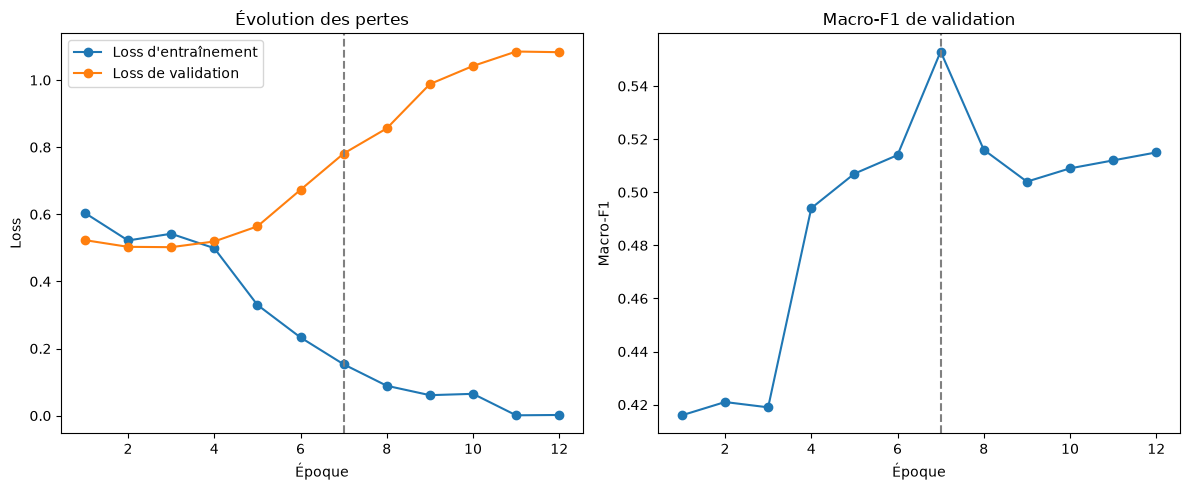

In [155]:
epochs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] # Numéros des époques (12 au total)

training_loss = [0.604, 0.522, 0.542, 0.499, 0.330, 0.233, 0.153, 0.089, 0.061, 0.065, 0.001, 0.002]
# Loss d'entraînement à chaque époque (décroît fortement)

validation_loss = [0.523, 0.503, 0.502, 0.519, 0.564, 0.673, 0.781, 0.856, 0.988, 1.042, 1.085, 1.083]
# Loss de validation à chaque époque (remonte à partir de l'époque 4)

macro_f1 = [0.416, 0.421, 0.419, 0.494, 0.507, 0.514, 0.553, 0.516, 0.504, 0.509, 0.512, 0.515]
# Macro-F1 de validation (pic à 0,553 à l'époque 7)

fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # Crée une figure avec 2 sous-graphiques côte à côte


# Evolution des pertes
axes[0].plot(epochs, training_loss, marker="o", label="Loss d'entraînement")
# Trace la courbe de la loss d'entraînement sur le 1er sous-graphique (graphe de gauche)
# epochs en abscisse, training_loss en ordonnée, marqueurs ronds et étiquette

axes[0].plot(epochs, validation_loss, marker="o", label="Loss de validation")
# Trace la loss de validation

axes[0].axvline(7, linestyle="--", color="gray") # Ligne verticale à l'époque 7 (meilleur modèle)

axes[0].set_title("Évolution des pertes") # Titre du sous-graphique
axes[0].set_xlabel("Époque") # Label de l'axe X
axes[0].set_ylabel("Loss") # Label de l'axe Y
axes[0].legend() # Affiche la légende


# Macro-F1
axes[1].plot(epochs, macro_f1, marker="o") # Trace le Macro-F1 de validation

axes[1].axvline(7, linestyle="--", color="gray") # Ligne verticale à l'époque 7

axes[1].set_title("Macro-F1 de validation") # Titre du sous-graphique
axes[1].set_xlabel("Époque") # Label de l'axe X
axes[1].set_ylabel("Macro-F1") # Label de l'axe Y


plt.tight_layout() # Ajuste automatiquement les espacements entre les 2 graphiques
plt.show() # Affiche la figure

## Entraînement final du modèle de sentiment

Le nombre de 7 epochs ayant été sélectionné à partir du jeu de validation, un nouveau modèle DistilBERT est maintenant entraîné sur l'ensemble des **4 279 annotations d'entraînement**.

Le jeu de test de **1 077 annotations** reste totalement séparé et sera utilisé une seule fois après cet entraînement pour l'évaluation finale.

### Préparation des labels pour l'entraînement final

Après la sélection du nombre d'epochs, l'ensemble des annotations d'entraînement est réutilisé pour entraîner le modèle final.

Les sentiments du jeu d'entraînement complet sont donc convertis avec le même encodage numérique que celui utilisé pendant la phase de validation.

In [157]:
train_sentiment["label"] = train_sentiment["sentiment"].map(label2id)
# Crée la colonne "label" en convertissant le sentiment texte en indice numérique
# remplace chaque valeur de la colonne par la valeur correspondante dans le dictionnaire

print(train_sentiment["label"].value_counts().sort_index())
# Affiche le décompte des labels triés par indice croissant

label
0    2111
1    1866
2     245
3      57
Name: count, dtype: int64


In [158]:
train_sentiment_final_encodings = tokenizer_sentiment(train_sentiment["texte_aspect"].astype(str).tolist(),
                                            # Tokenise les textes d'entraînement complets (aspect + avis)
                                                      truncation=True,
                                                      # Tronque les textes dépassant 128 tokens
                                                      padding="max_length",
                                                      # Complète chaque séquence à 128 tokens
                                                      max_length=128) # Longueur fixe : 128 tokens

dataset_train_sentiment_final = SentimentDataset(train_sentiment_final_encodings,
                                                 # Crée le Dataset PyTorch d'entraînement final
                                                 train_sentiment["label"].values) 
                                                 # Labels de sentiment (entiers 0-3)

print("TRAIN FINAL :", len(dataset_train_sentiment_final)) 
# Affiche le nombre d'exemples d'entraînement final

print("TEST :", len(dataset_test_sentiment)) # Affiche le nombre d'exemples de test (rappel)

TRAIN FINAL : 4279
TEST : 1077


### Modèle final de sentiment

Un nouveau modèle DistilBERT est initialisé afin d'effectuer l'entraînement final.

Le nombre de **7 epochs** a été déterminé précédemment à partir du jeu de validation, où le meilleur Macro-F1 a été obtenu.

Le modèle est maintenant entraîné sur l'ensemble des **4 279 annotations d'entraînement**. Aucun jeu de validation n'est utilisé pendant cette étape, puisque les hyperparamètres et le nombre d'epochs ont déjà été sélectionnés.

Les **1 077 annotations de test** restent totalement séparées et seront utilisées uniquement pour l'évaluation finale.

In [159]:
model_sentiment_final = AutoModelForSequenceClassification.from_pretrained(model_name_sentiment,
                                   # Charge DistilBERT pré-entraîné pour l'entraînement final du sentiment
                                                                           num_labels=4,
                 # Configure la tête de classification avec 4 sorties (negative, positive, mixed, neutral)
                                                                           id2label=id2label,
                                      # Associe chaque indice à un nom de classe (stocké dans config.json)
                                                                           label2id=label2id,
                                      # Associe chaque nom de classe à un indice (stocké dans config.json)
                                                            problem_type="single_label_classification")
                       # Configure Hugging Face pour un problème multi-classe (softmax + CrossEntropyLoss)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Initialisation de la tête de classification

Le modèle `distilbert-base-uncased` est chargé à partir de poids pré-entraînés.

Certaines couches utilisées lors du pré-entraînement ne sont pas nécessaires pour cette tâche de classification et sont donc ignorées. À l'inverse, les couches `pre_classifier` et `classifier`, spécifiques à la classification des quatre sentiments, sont nouvellement initialisées.

Cette situation est normale lors de l'adaptation d'un modèle pré-entraîné à une nouvelle tâche supervisée. Ces nouvelles couches seront apprises pendant le fine-tuning sur les 4 279 annotations d'entraînement.

### Configuration de l'entraînement final

Le modèle final est entraîné pendant 7 epochs avec les mêmes principaux hyperparamètres que ceux utilisés pendant la phase de sélection.

Aucune évaluation intermédiaire n'est nécessaire à ce stade puisque le nombre d'epochs a déjà été choisi à partir du jeu de validation.

In [160]:
training_args_sentiment_final = TrainingArguments(output_dir="./results_sentiment_final",
                        # Dossier de sauvegarde (ici non utilisé car pas de checkpoints)
                                                  num_train_epochs=7,
                                                  # Nombre d'époques : 7 (meilleure valeur identifiée)
                                                  per_device_train_batch_size=8,
                                                  # 8 exemples par pas d'entraînement
                                                  per_device_eval_batch_size=16,
                                                  # 16 exemples par lot d'évaluation
                                                  learning_rate=5e-5,
                                            # Taux d'apprentissage : 5 × 10⁻⁵ (classique pour DistilBERT)
                                                  weight_decay=0.01,
                                                  # Régularisation L2 pour limiter le sur-apprentissage
                                                  save_strategy="no",
                                                  # Aucune sauvegarde de checkpoint pendant l'entraînement
                                                  logging_steps=50,
                                                  # Log toutes les 50 mises à jour
                                                  report_to="none",
                                                # Désactive les outils de suivi externes (wandb, mlflow…)
                                                  seed=42, 
                                                  # Graine aléatoire fixée pour la reproductibilité
                                                  dataloader_pin_memory=False)
                                    # Désactive le pin_memory (économise la RAM / évite certains warnings)

In [161]:
trainer_sentiment_final = Trainer(model=model_sentiment_final,
                               # Modèle DistilBERT neuf pour l'entraînement final (4 classes de sentiment)
                                  args=training_args_sentiment_final,
                                  # Configuration finale (7 époques, save_strategy="no", seed=42)
                                  train_dataset=dataset_train_sentiment_final,
                                  # Dataset d'entraînement final (1 600 avis × aspects tokenisés)
                                  compute_metrics=compute_metrics_sentiment)
                                  # Fonction de calcul des métriques (accuracy, Macro-F1, Weighted-F1)

### Entraînement final

DistilBERT est maintenant entraîné sur l'ensemble des données d'entraînement pendant les 7 epochs retenues.

In [80]:
# trainer_sentiment_final.train() # Lance l'entraînement (fine-tuning) du modèle de sentiment

Step,Training Loss
50,0.904115
100,0.714455
150,0.697342
200,0.619176
250,0.686945
300,0.619084
350,0.625190
400,0.633457
450,0.598238
500,0.628981


TrainOutput(global_step=3745, training_loss=0.36579961859495524, metrics={'train_runtime': 8944.4223, 'train_samples_per_second': 3.349, 'train_steps_per_second': 0.419, 'total_flos': 991984377990144.0, 'train_loss': 0.36579961859495524, 'epoch': 7.0})

## Évaluation finale de DistilBERT sur le jeu de test

Après la sélection de 7 epochs à partir du jeu de validation, DistilBERT a été réentraîné sur l'ensemble des 4 279 annotations d'entraînement.

Le modèle est maintenant évalué une seule fois sur les **1 077 annotations du jeu de test**, restées totalement à l'écart pendant la sélection du nombre d'epochs.

Les métriques utilisées sont :

- **Accuracy** : proportion globale de prédictions correctes ;
- **Macro-F1** : moyenne des F1-scores des quatre classes en leur donnant le même poids ;
- **Weighted-F1** : moyenne des F1-scores pondérée par la fréquence de chaque classe.


In [222]:

#--------------------Bloc a lancer la toute prmeiere fois lors de l'entrainement--------------------#

#resultats_test_sentiment = trainer_sentiment_final.evaluate(dataset_test_sentiment) 
# Évalue le modèle sur le jeu de test (loss + métriques)

#print("Accuracy TEST :", resultats_test_sentiment["eval_accuracy"]) 
# Affiche l'accuracy : % de prédictions correctes

#print("Macro-F1 TEST :", resultats_test_sentiment["eval_macro_f1"]) 
# Affiche le Macro-F1 : moyenne non pondérée des F1 par classe

#print("Weighted-F1 TEST :", resultats_test_sentiment["eval_weighted_f1"]) 
# Affiche le Weighted-F1 : moyenne des F1 pondérée par le support

#print("Loss TEST :", resultats_test_sentiment["eval_loss"]) 
# Affiche la loss (entropie croisée) sur le test


#--------------------Bloc a lancer apres une relance du Notebook------------------------#

# Recharger le modèle de sentiment déjà fine-tuné
model_sentiment_charge = AutoModelForSequenceClassification.from_pretrained(
    "./distilbert_sentiment_final")

# Préparer le Trainer pour l'évaluation uniquement
trainer_eval = Trainer(model=model_sentiment_charge,
                       args=TrainingArguments(output_dir="./eval_sentiment",
                                              per_device_eval_batch_size=16,
                                              report_to="none"),
                       compute_metrics=compute_metrics_sentiment)

# Prédire sur les 1 077 couples avis–aspect du test
# Cette étape calcule également les métriques
predictions_test_sentiment = trainer_eval.predict(dataset_test_sentiment)

# Conserver les prédictions pour le rapport et la matrice de confusion
y_pred_sentiment = np.argmax(predictions_test_sentiment.predictions,
                             axis=1)

y_vrai_sentiment = test_sentiment["label"].values

# Récupérer les métriques calculées sur le test
resultats_test_sentiment = predictions_test_sentiment.metrics

print("Accuracy TEST :", round(resultats_test_sentiment["test_accuracy"], 3))
print("Macro-F1 TEST :", round(resultats_test_sentiment["test_macro_f1"], 3))
print("Weighted-F1 TEST :", round(resultats_test_sentiment["test_weighted_f1"], 3))
print("Loss TEST :", round(resultats_test_sentiment["test_loss"], 3))

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

\\?\C:\Users\soussi\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Accuracy TEST : 0.829
Macro-F1 TEST : 0.577
Weighted-F1 TEST : 0.83
Loss TEST : 0.836


## Résultats finaux - DistilBERT Sentiment

Le modèle DistilBERT final, entraîné pendant 7 epochs sur les 4 279 annotations d'entraînement, est évalué sur les 1 077 annotations du jeu de test.

| Métrique | Score |
|---|---:|
| Accuracy | **0,829** |
| Macro-F1 | **0,577** |
| Weighted-F1 | **0,830** |
| Loss | 0,836 |

Le Macro-F1 est particulièrement important dans cette tâche en raison du fort déséquilibre entre les quatre classes de sentiment.

Les résultats obtenus sur le jeu de test confirment que le modèle conserve de bonnes performances sur des données non utilisées pendant l'entraînement ou la sélection du nombre d'epochs.


### Sauvegarde du modèle final

Le modèle DistilBERT final et son tokenizer sont sauvegardés afin de pouvoir être réutilisés ultérieurement sans refaire le fine-tuning.

Le modèle DistilBERT fine-tuné et son tokenizer sont enregistrés dans le dossier `distilbert_sentiment_final`.

Cette cellule n'est exécutée qu'**une seule fois**, juste après l'entraînement final. Elle est ensuite mise en commentaire : si le notebook est relancé sans refaire l'entraînement, elle écraserait le modèle entraîné par un modèle non entraîné. Les cellules suivantes rechargent le modèle depuis ce dossier.

In [82]:
# Sauvegarde le modèle fine-tuné dans le dossier indiqué
# trainer_sentiment_final.save_model("./distilbert_sentiment_final")

# Sauvegarde le tokenizer associé dans le même dossier
# tokenizer_sentiment.save_pretrained("./distilbert_sentiment_final")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./distilbert_sentiment_final\\tokenizer_config.json',
 './distilbert_sentiment_final\\tokenizer.json')

### Performances par classe de sentiment

Les performances globales sont complétées par un rapport de classification afin d'analyser séparément les résultats obtenus pour les sentiments `negative`, `positive`, `mixed` et `neutral`.

Cette analyse est particulièrement importante pour les classes minoritaires `mixed` et `neutral`.

In [228]:
# Afficher les performances pour chaque sentiment
print(classification_report(y_vrai_sentiment, y_pred_sentiment,
                            # Affiche le rapport de classification (précision, rappel, F1)
                            target_names=["negative", "positive", "mixed", "neutral"],
                            # Associe les indices 0-3 aux noms des classes
                            digits=3, zero_division=0))
                            # 3 décimales ; 0 si division par zéro (classe jamais prédite)

              precision    recall  f1-score   support

    negative      0.860     0.891     0.875       551
    positive      0.876     0.828     0.852       454
       mixed      0.338     0.407     0.369        59
     neutral      0.333     0.154     0.211        13

    accuracy                          0.829      1077
   macro avg      0.602     0.570     0.577      1077
weighted avg      0.832     0.829     0.830      1077



### Analyse des performances par sentiment

Les performances sont élevées pour les deux classes majoritaires :

| Sentiment | Precision | Recall | F1-score | Support |
|---|---:|---:|---:|---:|
| negative | 0,860 | 0,891 | **0,875** | 551 |
| positive | 0,876 | 0,828 | **0,852** | 454 |
| mixed | 0,338 | 0,407 | **0,369** | 59 |
| neutral | 0,333 | 0,154 | **0,211** | 13 |



| Métrique | Precision | Recall | F1-score | Support |
|---|---:|---:|---:|---:|
| **Accuracy** | | | **0,829** | 1 077 |
| **Macro avg** | 0,602 | 0,570 | **0,577** | 1 077 |
| **Weighted avg** | 0,832 | 0,829 | 0,830 | 1 077 |

Le modèle distingue efficacement les sentiments `negative` et `positive`, qui représentent la grande majorité des annotations.

Les performances sont plus faibles pour `mixed` et surtout `neutral`. Cette difficulté est cohérente avec leur faible représentation dans le jeu d'entraînement et dans le jeu de test. La classe `neutral` ne contient notamment que 13 observations dans le test.

Cette différence entre classes explique l'écart entre :

- **Accuracy : 0,829**
- **Weighted-F1 : 0,830**
- **Macro-F1 : 0,577**

L'Accuracy et le Weighted-F1 sont fortement influencés par les classes majoritaires `negative` et `positive`, tandis que le Macro-F1 accorde le même poids aux quatre classes et reflète donc davantage les difficultés rencontrées sur `mixed` et `neutral`.

Malgré cette limite, DistilBERT obtient un Macro-F1 nettement supérieur aux modèles classiques testés précédemment.



### Comparaison des modèles - Classification du sentiment

Les modèles sont évalués sur les mêmes 1 077 couples avis–aspect du jeu de test. Les aspects fournis en entrée sont ceux des annotations.

| Modèle | Accuracy | Macro-F1 | Weighted-F1 |
|---|---:|---:|---:|
| Dummy majoritaire | 0,512 | 0,169 | 0,346 |
| Régression logistique | 0,758 | 0,436 | 0,758 |
| SVM | 0,784 | 0,431 | 0,768 |
| XGBoost | 0,773 | 0,407 | 0,750 |
| **DistilBERT** | **0,829** | **0,577** | **0,830** |

DistilBERT obtient les meilleurs scores observés sur les trois métriques.

Le Macro-F1 passe de **0,436** pour la régression logistique à **0,577**, soit un gain de **0,141**. L'accuracy dépasse celle du SVM de **4,5 points**, passant de **0,784 à 0,829**.

Par rapport au dummy majoritaire, DistilBERT apporte un gain de **31,7 points d'accuracy** et de **0,408 en Macro-F1**.

Les performances restent toutefois inégales selon les sentiments : `negative` et `positive` sont mieux reconnus que `mixed` et `neutral`.

Cette évaluation mesure la prédiction du sentiment lorsque l'aspect est fourni correctement. Elle ne mesure pas encore les performances de la chaîne complète de détection des aspects puis de classification de leurs sentiments.

### Matrice de confusion des sentiments

La matrice de confusion permet d'identifier les classes avec lesquelles les sentiments sont principalement confondus.

Cette analyse complète les métriques globales et permet notamment de mieux comprendre les performances plus faibles observées pour les classes `mixed` et `neutral`.

Sentiment prédit,negative,positive,mixed,neutral
Sentiment réel,,,,
negative,491,33,24,3
positive,54,376,23,1
mixed,17,18,24,0
neutral,9,2,0,2


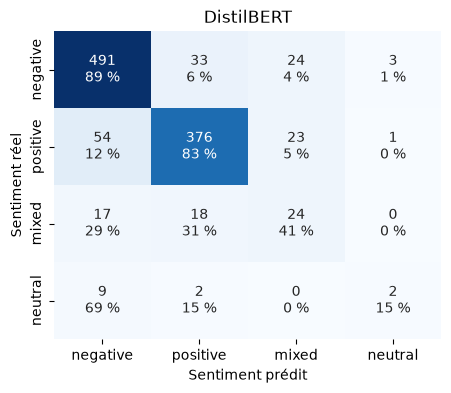

In [194]:
# Ordre logique des sentiments
ordre_sentiments = ["negative", "positive", "mixed", "neutral"]

# Convertir les codes (0, 1, 2, 3) en noms de sentiments
y_true_noms = pd.Series(y_vrai_sentiment).map(id2label)
y_pred_noms = pd.Series(y_pred_sentiment).map(id2label)

# Matrice de confusion, réordonnée selon l'ordre logique
matrice_confusion_sentiment = pd.crosstab(y_true_noms, y_pred_noms,
                                          rownames=["Sentiment réel"],
                                          colnames=["Sentiment prédit"]).reindex(index=ordre_sentiments,
                                                                                 columns=ordre_sentiments,
                                                                                 fill_value=0)
display(matrice_confusion_sentiment)

# Pourcentages par ligne (chaque ligne fait 100 %)
matrice_pct = matrice_confusion_sentiment.div(matrice_confusion_sentiment.sum(axis=1), axis=0) * 100

# Texte des cases : effectif + pourcentage
annotations = (matrice_confusion_sentiment.astype(str) + "\n"
               + matrice_pct.round(0).astype(int).astype(str) + " %")

# Heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(matrice_confusion_sentiment, annot=annotations, fmt="", cmap="Blues", cbar=False)
plt.title("DistilBERT")
plt.xlabel("Sentiment prédit")
plt.ylabel("Sentiment réel")
plt.show()

### Interprétation de la matrice de confusion

La matrice de confusion montre que DistilBERT reconnaît correctement la majorité des sentiments `negative` et `positive`.

- Sur **551** annotations `negative`, **491** sont correctement classées, soit un rappel d'environ **89 %**.
- Sur **454** annotations `positive`, **376** sont correctement classées, soit un rappel d'environ **83 %**.

Les principales difficultés concernent les classes minoritaires :

- Sur **59** annotations `mixed`, seulement **24** sont correctement identifiées. Les autres sont principalement confondues avec `negative` (**17**) ou `positive` (**18**). Cette confusion est cohérente avec la nature de la classe `mixed`, qui contient simultanément des éléments positifs et négatifs.
- Sur **13** annotations `neutral`, seulement **2** sont correctement détectées. La majorité est prédite comme `negative` (**9**). Le très faible nombre d'exemples `neutral` dans les données d'entraînement limite fortement l'apprentissage de cette classe.

La matrice montre également que les erreurs entre les deux classes majoritaires restent relativement limitées : **33** avis réellement négatifs sont prédits positifs et **54** avis réellement positifs sont prédits négatifs.

Ainsi, DistilBERT obtient de bonnes performances sur les sentiments dominants, mais les classes `mixed` et surtout `neutral` restent difficiles à modéliser en raison de leur faible représentation dans le corpus.

# Conclusion — Modélisation Deep Learning

Deux modèles DistilBERT distincts ont été fine-tunés pour répondre aux deux tâches supervisées du projet.

### Tâche 1 — Détection des aspects

DistilBERT atteint sur le jeu de test :

- **Micro-F1 : 0,745**
- **Macro-F1 : 0,585**

Le Transformer améliore les performances obtenues avec les modèles classiques basés sur TF-IDF.

### Tâche 2 — Sentiment par aspect

DistilBERT atteint :

- **Accuracy : 0,829**
- **Macro-F1 : 0,577**
- **Weighted-F1 : 0,830**

Les sentiments `negative` et `positive` sont bien reconnus, tandis que les classes minoritaires `mixed` et surtout `neutral` restent plus difficiles à identifier.

Dans les deux tâches, DistilBERT apporte une amélioration par rapport aux approches classiques, montrant l'intérêt d'une représentation contextuelle du texte pour l'analyse des avis Trustpilot.

# Pipeline final - Avis -> Aspects -> Sentiments

L'objectif final du projet est d'enchaîner les deux modèles DistilBERT entraînés :

1. le premier modèle détecte les aspects présents dans un avis ;
2. chaque aspect détecté est ensuite associé au texte de l'avis ;
3. le second modèle prédit le sentiment correspondant à chaque aspect.

Le pipeline transforme ainsi un avis libre en une sortie structurée exploitable par une entreprise.

In [213]:
tokenizer_aspects = AutoTokenizer.from_pretrained("./distilbert_aspects_final")
# Charge le tokenizer DistilBERT sauvegardé pour la détection d'aspects

model_aspects = AutoModelForSequenceClassification.from_pretrained("./distilbert_aspects_final")
# Charge le modèle DistilBERT de classification d'aspects (fine-tuné, multi-label)

tokenizer_sentiment_final = AutoTokenizer.from_pretrained("./distilbert_sentiment_final")
# Charge le tokenizer DistilBERT sauvegardé pour l'analyse de sentiment

model_sentiment_final = AutoModelForSequenceClassification.from_pretrained("./distilbert_sentiment_final")
# Charge le modèle DistilBERT de classification de sentiment (fine-tuné, multi-classe)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

## Fonction de prédiction finale

La fonction suivante reçoit un avis en texte libre.

Le modèle de détection des aspects calcule d'abord la probabilité de présence de chacun des 18 aspects. Les aspects dont la probabilité est supérieure ou égale à **0,5** sont conservés.

Pour chaque aspect détecté, une nouvelle entrée `aspect + texte de l'avis` est ensuite construite et transmise au modèle de sentiment.

La sortie finale contient ainsi, pour chaque aspect détecté, son sentiment associé.


In [215]:
def analyser_avis(texte): # Définition de la fonction qui prend un avis en entrée
    model_aspects.eval() # Passe le modèle d'aspects en mode évaluation (désactive Dropout)
    model_sentiment_final.eval() # Passe le modèle de sentiment en mode évaluation

 # Tokenise le texte pour le modèle d'aspects (tenseurs PyTorch, 128 tokens max)
    inputs_aspects = tokenizer_aspects(texte, # Tokenise le texte pour le modèle d'aspects
                                       return_tensors="pt", # Retourne des tenseurs PyTorch
                                       truncation=True, # Tronque au-delà de 128 tokens
                                       padding=True, # Padding dynamique
                                       max_length=128) # Longueur maximale : 128 tokens

    with torch.no_grad(): # Désactive le calcul de gradient (mode inférence)
        logits_aspects = model_aspects(**inputs_aspects).logits 
        # Prédit les logits bruts pour chaque aspect

    
    probabilites_aspects = torch.sigmoid(logits_aspects)[0].numpy()
    # Convertit les logits en probabilités (sigmoïde, multi-label)
    
    aspects_detectes = [aspects[i] for i, proba in enumerate(probabilites_aspects) if proba >= 0.5]
    # Garde les aspects dont la probabilité dépasse le seuil de 0,5
    
    resultats = [] # Initialise la liste des résultats

    for aspect in aspects_detectes: # Boucle sur chaque aspect détecté
        texte_aspect = aspect + " " + texte 
        # Préfixe le texte par le nom de l'aspect (entrée du modèle de sentiment)
        
        inputs_sentiment = tokenizer_sentiment_final(texte_aspect, 
                                                # Tokenise ce texte-aspect pour le modèle de sentiment
                                                     return_tensors="pt", # Tenseurs PyTorch
                                                     truncation=True, # Tronque au-delà de 128 tokens
                                                     padding=True, # Padding dynamique
                                                     max_length=128) # Longueur maximale : 128 tokens

        with torch.no_grad(): # Idem : mode inférence
            
            logits_sentiment = model_sentiment_final(**inputs_sentiment).logits
            # Prédit les logits de sentiment pour cet aspect
            
        sentiment_id = torch.argmax(logits_sentiment, dim=1).item() 
        # Récupère l'indice de la classe de sentiment prédite
        sentiment = id2label[sentiment_id] # Traduit l'indice en label lisible (ex. "positif")

        resultats.append({"aspect": aspect, "sentiment": sentiment}) 
        # Ajoute un dictionnaire {aspect, sentiment} aux résultats

    return pd.DataFrame(resultats) # Retourne le tout sous forme de DataFrame pandas

### Test du pipeline sur un nouvel avis

Le pipeline est testé sur un exemple contenant plusieurs dimensions de l'expérience client afin de vérifier que les aspects et leurs sentiments peuvent être prédits simultanément.

In [216]:
avis_test = "The delivery was very late, but the customer service was excellent and very helpful."
# Définit un avis de test (en anglais, contenant plusieurs aspects)

analyser_avis(avis_test) # Appelle la fonction pour détecter les aspects et leur sentiment

,aspect,sentiment
0,customer service,positive
1,delivery,negative


## Conclusion du pipeline final

Le pipeline final permet maintenant de transformer automatiquement un avis Trustpilot en information structurée.

Le traitement s'effectue en deux étapes :

1. **Détection des aspects** avec le modèle DistilBERT entraîné sur les 18 aspects métier ;
2. **Classification du sentiment** pour chaque aspect détecté avec le second modèle DistilBERT.

Le fonctionnement final peut être résumé ainsi :

**Avis client → aspect(s) détecté(s) → sentiment associé à chaque aspect**

Cette architecture permet par exemple de transformer un avis tel que :

> *The delivery was very late, but the customer service was excellent and very helpful.*

en une sortie structurée de la forme :

| Aspect | Sentiment |
|---|---|
| delivery | negative |
| customer service | positive |

Les deux tâches restent séparées, ce qui permet d'évaluer indépendamment la qualité de la détection des aspects et celle de la classification du sentiment, tout en pouvant les enchaîner dans un même pipeline pour une utilisation finale.

## Comparaison finale de tous les modèles sur le jeu de test

Les scores des modèles classiques et des références naïves proviennent des notebooks `ML_Trustpilot_aspects`et `ML_Trustpilot_sentiments`.

Ils sont repris ici pour les comparer à DistilBERT, évalué sur les mêmes jeux de test. Les valeurs présentées sont arrondies à trois décimales.

Les scores de DistilBERT sont calculés dans ce notebook, après rechargement des modèles fine-tunés sauvegardés.

Jeux de test : **400 avis pour les aspects** et **1 077 couples avis–aspect pour les sentiments**.

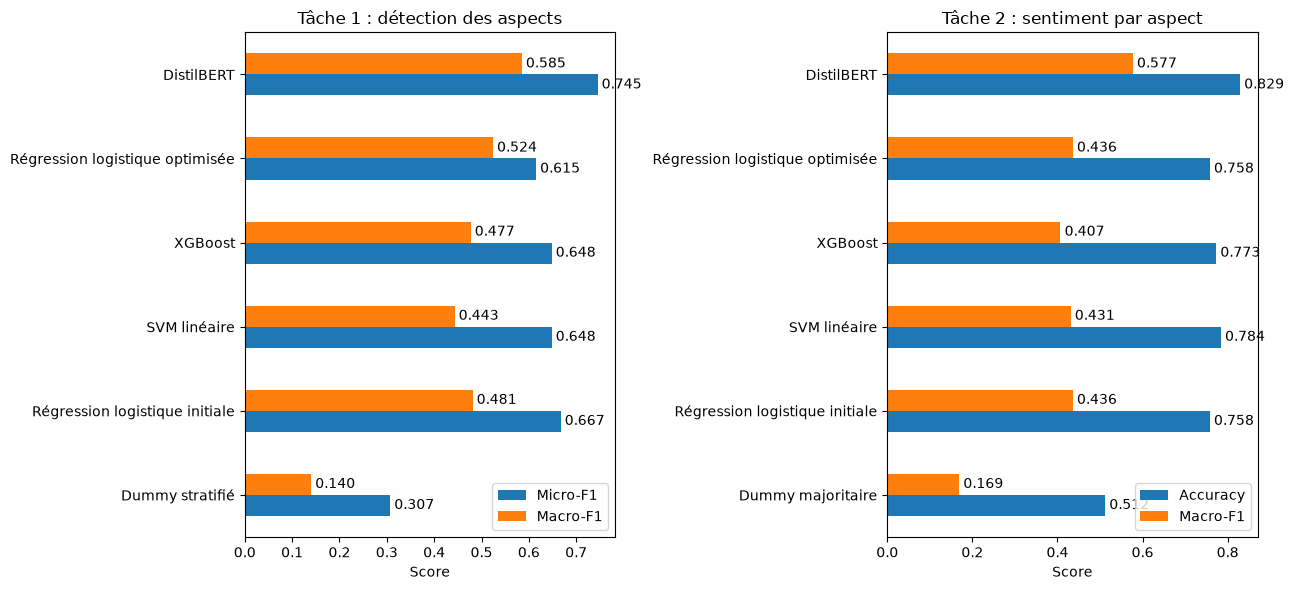

In [239]:
# Résultats sur le test : détection des aspects tâche 1
comparaison_aspects = pd.DataFrame({ # Crée le tableau comparatif des modèles de la tâche 1 (aspects)
    "Modèle": ["Dummy stratifié", "Régression logistique initiale", "SVM linéaire",
               "XGBoost", "Régression logistique optimisée", "DistilBERT"], # Liste des 6 modèles comparés
    "Micro-F1": [0.307, 0.667, 0.648, 0.648, 0.615, 0.745], # Micro-F1 de chaque modèle
    "Macro-F1": [0.140, 0.481, 0.443, 0.477, 0.524, 0.585]}) # Macro-F1 de chaque modèle

# Résultats sur le test : sentiment par aspect tâche 2
comparaison_sentiment = pd.DataFrame({
    "Modèle": ["Dummy majoritaire", "Régression logistique initiale", "SVM linéaire",
               "XGBoost", "Régression logistique optimisée", "DistilBERT"],
    "Accuracy": [0.512, 0.758, 0.784, 0.773, 0.758, 0.829],
    "Macro-F1": [0.169, 0.436, 0.431, 0.407, 0.436, 0.577]})

fig, axes = plt.subplots(1, 2, figsize=(13, 6)) # Crée une figure avec 2 sous-graphiques côte à côte


# Tâche 1
comparaison_aspects.set_index("Modèle").plot(kind="barh", ax=axes[0]) 
# Barres horizontales : modèles en Y, métriques en X (tâche 1)

axes[0].set_title("Tâche 1 : détection des aspects") # Titre du sous-graphique de gauche
axes[0].set_xlabel("Score") # Label de l'axe X
axes[0].set_ylabel("") # Vide (les noms de modèles sont déjà en Y)


# Tâche 2
comparaison_sentiment.set_index("Modèle").plot(kind="barh", ax=axes[1])
# Barres horizontales : modèles en Y, métriques en X (tâche 2)

axes[1].set_title("Tâche 2 : sentiment par aspect") # Titre du sous-graphique de droite
axes[1].set_xlabel("Score") # Label de l'axe X
axes[1].set_ylabel("") # Supprime le label de l'axe Y (noms de modèles déjà affichés)

# valeurs
for ax in axes: # Boucle sur les 2 sous-graphiques
    for barres in ax.containers: # Parcourt les conteneurs de barres (un par métrique)
        ax.bar_label(barres, fmt="%.3f", padding=3) 
        # Affiche la valeur numérique au bout de chaque barre (3 décimales)

plt.tight_layout() # Ajuste automatiquement les espacements
plt.show() # Affiche la figure

In [241]:
# Afficher le tableau comparatif pour les aspects
print("Tâche 1 — Détection des aspects")
display(comparaison_aspects.round(3))

# Afficher le tableau comparatif pour les sentiments
print("Tâche 2 — Sentiment par aspect")
display(comparaison_sentiment.round(3))

Tâche 1 — Détection des aspects


,Modèle,Micro-F1,Macro-F1
0,Dummy stratifié,0.307,0.140
1,Régression logistique initiale,0.667,0.481
2,SVM linéaire,0.648,0.443
3,XGBoost,0.648,0.477
4,Régression logistique optimisée,0.615,0.524
5,DistilBERT,0.745,0.585


Tâche 2 — Sentiment par aspect


,Modèle,Accuracy,Macro-F1
0,Dummy majoritaire,0.512,0.169
1,Régression logistique initiale,0.758,0.436
2,SVM linéaire,0.784,0.431
3,XGBoost,0.773,0.407
4,Régression logistique optimisée,0.758,0.436
5,DistilBERT,0.829,0.577


### Analyse comparative des résultats

#### Détection des aspects

DistilBERT obtient les meilleurs résultats parmi les configurations évaluées, avec un **Micro-F1 de 0,745** et un **Macro-F1 de 0,585**.

Par rapport au meilleur modèle classique pour chaque métrique, les gains sont :

- **+0,078 en Micro-F1** par rapport à la régression logistique initiale, qui atteint 0,667 ;
- **+0,061 en Macro-F1** par rapport à la régression logistique optimisée, qui atteint 0,524.

DistilBERT améliore donc à la fois le score calculé sur l'ensemble des détections et la moyenne des F1 des 18 aspects. Cette amélioration globale ne signifie cependant pas qu'il est meilleur sur chaque aspect pris séparément.

L'optimisation de la régression logistique fait apparaître un compromis. Son Macro-F1 passe de **0,481 à 0,524**, mais son Micro-F1 diminue de **0,667 à 0,615**. Elle améliore notamment le F1 de `return` et de `cleanliness`, tandis que celui de `communication` diminue. Le meilleur Macro-F1 ne correspond donc pas à une amélioration uniforme des 18 aspects.

Ce compromis concerne aussi l'utilisation du modèle : après optimisation, la précision atteint seulement **0,344 pour `communication`** et **0,303 pour `trustworthiness`**. Pour ces aspects, de nombreuses détections sont incorrectes par rapport aux annotations. Une utilisation destinée à déclencher automatiquement des actions métier nécessiterait de tenir compte de ces faux positifs.

Le SVM et XGBoost obtiennent le même Micro-F1 arrondi (**0,648**), mais XGBoost présente un meilleur Macro-F1 (**0,477 contre 0,443**). Il reste proche de la LR initiale sur cette métrique, sans dépasser les meilleures performances classiques.

#### Prédiction du sentiment par aspect

DistilBERT obtient également les meilleurs résultats pour cette tâche : **Accuracy = 0,829** et **Macro-F1 = 0,577**.

Il dépasse :

- le SVM, meilleur modèle classique en accuracy, de **4,5 points de pourcentage** : 82,9 % contre 78,4 % ;
- la régression logistique, meilleur modèle classique en Macro-F1, de **0,141** : 0,577 contre 0,436.

Les modèles classiques présentent déjà un compromis entre les métriques : le SVM classe correctement davantage de couples avis–aspect, mais la LR obtient une moyenne des F1 légèrement supérieure. L'écart de Macro-F1 entre eux reste faible (**0,005**).

Contrairement à la tâche des aspects, l'optimisation de la LR n'améliore pas les résultats. La recherche retient **C = 1**, valeur déjà utilisée par le modèle initial. Les deux lignes du tableau présentent donc les mêmes scores.

Les rapports de classification permettent de préciser l'apport de DistilBERT. Le F1 de `mixed` atteint **0,369**, contre environ **0,13 pour la LR**, et celui de `neutral` atteint **0,211**, alors qu'aucun des modèles classiques ne détecte correctement cette classe.

Ces progrès restent toutefois limités : les F1 de `negative` (**0,875**) et de `positive` (**0,852**) demeurent nettement supérieurs. DistilBERT reconnaît seulement **2 des 13 exemples `neutral`** du test. Une accuracy de 82,9 % ne signifie donc pas que les quatre sentiments sont reconnus avec la même fiabilité.

#### Apport des modèles et limites de la comparaison

Tous les modèles exploitant les textes dépassent les références naïves sur les métriques présentées. Les dummies permettent ainsi de vérifier que les résultats vont au-delà de prédictions fondées uniquement sur la répartition des labels.

Plusieurs limites doivent néanmoins accompagner cette comparaison :

- **Les classes rares sont peu représentées dans le test.** Certains aspects comptent seulement 6 ou 8 exemples, et le sentiment `neutral` en compte 13. Quelques prédictions peuvent donc modifier sensiblement leur F1. Les écarts observés ne suffisent pas à démontrer une amélioration statistiquement significative.
- **Le test mélange GOLD et SILVER.** Pour les annotations SILVER, les scores mesurent l'accord avec les labels produits par le LLM. L'évaluation séparée réalisée pour les modèles classiques d'aspects apporte un éclairage complémentaire, mais elle n'a pas été étendue ici à DistilBERT.
- **Le protocole de sélection comporte une limite pour les sentiments.** Le choix de la LR à optimiser s'est appuyé sur les premiers résultats du test. L'optimisation de son paramètre C a ensuite été réalisée sur le train avec GroupKFold.
- **Les deux tâches sont évaluées séparément.** Pour le sentiment, les aspects sont fournis par les annotations. Ces scores ne mesurent donc pas les performances de la chaîne complète dans laquelle les aspects sont d'abord prédits.

Les résultats soutiennent le choix de **DistilBERT pour les deux tâches sur ce jeu de test**. La régression logistique reste une référence utile, notamment pour examiner les coefficients associés aux termes. Le principal point à améliorer reste la fiabilité des prédictions sur les aspects et sentiments peu représentés.

*Les écarts présentés sont calculés à partir des scores arrondis à trois décimales.*

# Conclusion
Sur le jeu de test, **DistilBERT** donne les **meilleurs** résultats pour les deux tâches. Il atteint un Micro-F1 de 0,745 et un Macro-F1 de 0,585 pour la détection des aspects, puis une accuracy de 0,829 et un Macro-F1 de 0,577 pour le sentiment. Les modèles classiques obtiennent tout de même des résultats corrects, mais restent moins performants globalement, surtout sur les classes les plus difficiles.

DistilBERT est un modèle pré-entraîné sur un grand corpus de textes, ce qui lui permet de réutiliser des connaissances linguistiques déjà apprises malgré la taille relativement limitée de notre corpus annoté. Cela peut expliquer ses meilleures performances, notamment sur la détection des aspects et le sentiment par aspect.